In [1]:
# ============================================================================
# IMPORTS
# ============================================================================
import pandas as pd
import numpy as np

# Load Data 

In [2]:
# ============================================================================
# STEP 1: Load Human-Labeled Data (Train/Test Split)
# ============================================================================
# These are the video IDs that were manually labeled by humans
# and already split into training and test sets

# Load human-labeled training video IDs
human_labeled_train_video_ids = pd.read_csv('data/train_y.csv').set_index("video_id").index.to_list()

# Load human-labeled test video IDs
human_labeled_test_video_ids = pd.read_csv('data/test_y.csv').set_index("video_id").index.to_list()

# ============================================================================
# STEP 2: Load AI-Labeled Data
# ============================================================================
# Load the AI-labeled dataset (contains video_id and is_understandable labels)
ai_labeled_data = pd.read_excel('data/youtube_database_AI.xlsx', sheet_name='LabeledVideos')
# Keep only video_id and is_understandable columns, set video_id as index
ai_labeled_data = ai_labeled_data.loc[:, ["video_id", "is_understandable"]].set_index("video_id")

print(f"✅ Loaded {len(human_labeled_train_video_ids)} human-labeled training videos")
print(f"✅ Loaded {len(human_labeled_test_video_ids)} human-labeled test videos")
print(f"✅ Loaded {len(ai_labeled_data)} AI-labeled videos")

✅ Loaded 140 human-labeled training videos
✅ Loaded 50 human-labeled test videos
✅ Loaded 1163 AI-labeled videos


In [3]:
# ============================================================================
# STEP 3: Load Feature Data Files First (to check available video IDs)
# ============================================================================
# Load feature files to see which video IDs are available in the feature data
print("📂 Loading feature files...")
x_train_features_raw = pd.read_csv('data/x_train_scaled.csv').set_index("video_id")
x_test_features_raw = pd.read_csv('data/x_test_scaled.csv').set_index("video_id")

available_train_video_ids = set(x_train_features_raw.index)
available_test_video_ids = set(x_test_features_raw.index)

print(f"   - Available training video IDs in features: {len(available_train_video_ids)}")
print(f"   - Available test video IDs in features: {len(available_test_video_ids)}")

# ============================================================================
# STEP 4: Extract AI-Labeled Data for Train/Test Sets
# ============================================================================
# Find AI-labeled videos that match the human-labeled train/test splits
# AND have features available in the feature files

# Get AI-labeled video IDs that are in the human training set
ai_labeled_train_video_ids_all = ai_labeled_data[
    ai_labeled_data.index.isin(human_labeled_train_video_ids)
].index.to_list()

# Get AI-labeled video IDs that are in the human test set
ai_labeled_test_video_ids_all = ai_labeled_data[
    ai_labeled_data.index.isin(human_labeled_test_video_ids)
].index.to_list()

# Filter to only include video IDs that have features available
ai_labeled_train_video_ids = [
    vid for vid in ai_labeled_train_video_ids_all 
    if vid in available_train_video_ids
]

ai_labeled_test_video_ids = [
    vid for vid in ai_labeled_test_video_ids_all 
    if vid in available_test_video_ids
]

# Report any missing videos
missing_train_videos = set(ai_labeled_train_video_ids_all) - set(ai_labeled_train_video_ids)
missing_test_videos = set(ai_labeled_test_video_ids_all) - set(ai_labeled_test_video_ids)

if missing_train_videos:
    print(f"\n⚠️  Warning: {len(missing_train_videos)} training videos have AI labels but no features:")
    print(f"   Missing video IDs: {list(missing_train_videos)[:5]}..." if len(missing_train_videos) > 5 else f"   Missing video IDs: {list(missing_train_videos)}")

if missing_test_videos:
    print(f"\n⚠️  Warning: {len(missing_test_videos)} test videos have AI labels but no features:")
    print(f"   Missing video IDs: {list(missing_test_videos)[:5]}..." if len(missing_test_videos) > 5 else f"   Missing video IDs: {list(missing_test_videos)}")

# ============================================================================
# STEP 5: Filter Feature Data (X) to Match Available Video IDs
# ============================================================================
# Now safely filter features using only video IDs that exist in both datasets

# Filter training features to only include videos with both AI labels and features
x_train_features = x_train_features_raw.loc[ai_labeled_train_video_ids]

# Filter test features to only include videos with both AI labels and features
x_test_features = x_test_features_raw.loc[ai_labeled_test_video_ids]

# ============================================================================
# STEP 6: Extract Labels (y) for Train/Test Sets
# ============================================================================
# Get AI labels for videos that have both labels and features

# Training labels
train_labels_ai = ai_labeled_data[ai_labeled_data.index.isin(ai_labeled_train_video_ids)]

# Test labels
test_labels_ai = ai_labeled_data[ai_labeled_data.index.isin(ai_labeled_test_video_ids)]

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "=" * 80)
print("DATA SUMMARY")
print("=" * 80)
print(f"📊 Training set:")
print(f"   - AI-labeled training video IDs (with features): {len(ai_labeled_train_video_ids)}")
print(f"   - Training features shape: {x_train_features.shape}")
print(f"   - Training labels shape: {train_labels_ai.shape}")
print(f"\n📊 Test set:")
print(f"   - AI-labeled test video IDs (with features): {len(ai_labeled_test_video_ids)}")
print(f"   - Test features shape: {x_test_features.shape}")
print(f"   - Test labels shape: {test_labels_ai.shape}")
print("=" * 80)

📂 Loading feature files...
   - Available training video IDs in features: 133
   - Available test video IDs in features: 49

⚠️  Warning: 7 training videos have AI labels but no features:
   Missing video IDs: ['rwFOG_rk4Nk', 'i1Tb5gfymfU', 'lxVGPACR5ok', 'aKmcTOY4N0M', 'DgBYYFwd42A']...

⚠️  Warning: 1 test videos have AI labels but no features:
   Missing video IDs: ['3aUEf7VZLas']

DATA SUMMARY
📊 Training set:
   - AI-labeled training video IDs (with features): 129
   - Training features shape: (129, 31)
   - Training labels shape: (129, 1)

📊 Test set:
   - AI-labeled test video IDs (with features): 48
   - Test features shape: (48, 31)
   - Test labels shape: (48, 1)


In [4]:
# ============================================================================
# STEP 6: Expand Training Set with Additional AI-Labeled Videos
# ============================================================================
# Strategy: Sample additional videos from unlabeled pool and add them to training set
# This increases the training data size using AI labels

# ============================================================================
# STEP 6.1: Load Candidate Videos (Unlabeled Pool)
# ============================================================================
# These are videos that haven't been used in train/test split yet
# but have AI labels available
candidate_video_ids = pd.read_csv('data/to_predict_x.csv').set_index("video_id").index.to_list()
print(f"📋 Total candidate videos available: {len(candidate_video_ids)}")

# ============================================================================
# STEP 6.2: Randomly Sample Videos from Candidate Pool
# ============================================================================
# Sample a subset of videos to add to training set
np.random.seed(42)  # For reproducibility
n_samples_to_add = 900  # Number of videos to sample
sampled_candidate_video_ids = np.random.choice(
    candidate_video_ids, 
    size=n_samples_to_add, 
    replace=False  # No duplicates
)
print(f"✅ Randomly sampled {len(sampled_candidate_video_ids)} videos from candidate pool")

# ============================================================================
# STEP 6.3: Filter to Only Videos with Both AI Labels AND Features
# ============================================================================
# Only keep sampled videos that have:
# 1. AI labels in our dataset
# 2. Features available in to_predict_x.csv

# First, check which candidate videos have features
candidate_features = pd.read_csv('data/to_predict_x.csv').set_index("video_id")
available_candidate_video_ids = set(candidate_features.index)

# Filter sampled videos to only those with AI labels
sampled_videos_with_ai_labels = ai_labeled_data[
    ai_labeled_data.index.isin(sampled_candidate_video_ids)
].index.to_list()

# Further filter to only those with features available
new_train_video_ids_from_sampling = [
    vid for vid in sampled_videos_with_ai_labels 
    if vid in available_candidate_video_ids
]

print(f"✅ Found {len(sampled_videos_with_ai_labels)} sampled videos with AI labels")
print(f"✅ Found {len(new_train_video_ids_from_sampling)} sampled videos with both AI labels and features")

# Report any missing features
missing_features = set(sampled_videos_with_ai_labels) - set(new_train_video_ids_from_sampling)
if missing_features:
    print(f"⚠️  Warning: {len(missing_features)} videos have AI labels but no features (will be skipped)")

# ============================================================================
# STEP 6.4: Merge New Videos into Training Set
# ============================================================================
# Add the newly sampled videos to the existing training video IDs
# Note: Using extend() to merge lists (not append() which adds a single element)
ai_labeled_train_video_ids.extend(new_train_video_ids_from_sampling)

# ============================================================================
# STEP 6.5: Update Training Labels (y)
# ============================================================================
# Get all AI labels for the expanded training set
final_train_labels_ai = ai_labeled_data[
    ai_labeled_data.index.isin(ai_labeled_train_video_ids)
]

# ============================================================================
# STEP 6.6: Update Training Features (X)
# ============================================================================
# Extract features for the newly sampled videos (already loaded in step 6.3)
x_train_new_samples = candidate_features.loc[new_train_video_ids_from_sampling]

# Concatenate original training features with new samples
x_train_features = pd.concat([x_train_features, x_train_new_samples])

# ============================================================================
# Final Summary
# ============================================================================
print("\n" + "=" * 80)
print("EXPANDED TRAINING SET SUMMARY")
print("=" * 80)
print(f"📊 Original training set:")
print(f"   - Video count: {len(ai_labeled_train_video_ids) - len(new_train_video_ids_from_sampling)}")
print(f"\n📊 Newly added videos:")
print(f"   - Video count: {len(new_train_video_ids_from_sampling)}")
print(f"\n📊 Final expanded training set:")
print(f"   - Total video count: {len(ai_labeled_train_video_ids)}")
print(f"   - Training labels shape: {final_train_labels_ai.shape}")
print(f"   - Training features shape: {x_train_features.shape}")
print("=" * 80)


📋 Total candidate videos available: 2297
✅ Randomly sampled 900 videos from candidate pool
✅ Found 376 sampled videos with AI labels
✅ Found 376 sampled videos with both AI labels and features

EXPANDED TRAINING SET SUMMARY
📊 Original training set:
   - Video count: 129

📊 Newly added videos:
   - Video count: 376

📊 Final expanded training set:
   - Total video count: 505
   - Training labels shape: (505, 1)
   - Training features shape: (505, 31)


# Modelling


In [ ]:
x_train = x_train_features.sort_index()
y_train = final_train_labels_ai.sort_index()


x_test = x_test_features.sort_index()
y_test = test_labels_ai.sort_index()


In [6]:
# ============================================================================
# DATA ALIGNMENT VERIFICATION
# ============================================================================
# Verify that X (features) and y (labels) are properly aligned by video_id
# This is critical for model training - mismatched indices will cause errors

print("=" * 80)
print("VERIFYING DATA ALIGNMENT")
print("=" * 80)

# ============================================================================
# Training Set Alignment Check
# ============================================================================
print("\n📊 Training Set Alignment:")
print(f"   x_train shape: {x_train.shape}")
print(f"   y_train shape: {y_train.shape}")

# Check if indices match
train_indices_match = x_train.index.equals(y_train.index)
print(f"   ✅ Indices match: {train_indices_match}")

if not train_indices_match:
    print("\n   ⚠️  WARNING: Training set indices do not match!")
    # Find differences
    train_x_only = set(x_train.index) - set(y_train.index)
    train_y_only = set(y_train.index) - set(x_train.index)
    
    if train_x_only:
        print(f"   - Videos in x_train but not in y_train: {len(train_x_only)}")
        print(f"     Examples: {list(train_x_only)[:3]}")
    if train_y_only:
        print(f"   - Videos in y_train but not in x_train: {len(train_y_only)}")
        print(f"     Examples: {list(train_y_only)[:3]}")
else:
    print("   ✅ All training video IDs are aligned correctly!")

# ============================================================================
# Test Set Alignment Check
# ============================================================================
print("\n📊 Test Set Alignment:")
print(f"   x_test shape: {x_test.shape}")
print(f"   y_test shape: {y_test.shape}")

# Check if indices match
test_indices_match = x_test.index.equals(y_test.index)
print(f"   ✅ Indices match: {test_indices_match}")

if not test_indices_match:
    print("\n   ⚠️  WARNING: Test set indices do not match!")
    # Find differences
    test_x_only = set(x_test.index) - set(y_test.index)
    test_y_only = set(y_test.index) - set(x_test.index)
    
    if test_x_only:
        print(f"   - Videos in x_test but not in y_test: {len(test_x_only)}")
        print(f"     Examples: {list(test_x_only)[:3]}")
    if test_y_only:
        print(f"   - Videos in y_test but not in x_test: {len(test_y_only)}")
        print(f"     Examples: {list(test_y_only)[:3]}")
else:
    print("   ✅ All test video IDs are aligned correctly!")

# ============================================================================
# Detailed Comparison DataFrame (for inspection if needed)
# ============================================================================
# Create comparison DataFrames for detailed inspection
train_comparison = pd.DataFrame({
    'x_train_index': x_train.index,
    'y_train_index': y_train.index
})
train_comparison['indices_match'] = train_comparison['x_train_index'] == train_comparison['y_train_index']

test_comparison = pd.DataFrame({
    'x_test_index': x_test.index,
    'y_test_index': y_test.index
})
test_comparison['indices_match'] = test_comparison['x_test_index'] == test_comparison['y_test_index']

print("\n" + "=" * 80)
print("DETAILED ALIGNMENT SUMMARY")
print("=" * 80)
print(f"\n📊 Training Set:")
print(f"   Total videos: {len(train_comparison)}")
print(f"   Matching indices: {train_comparison['indices_match'].sum()}")
print(f"   Mismatched indices: {(~train_comparison['indices_match']).sum()}")

print(f"\n📊 Test Set:")
print(f"   Total videos: {len(test_comparison)}")
print(f"   Matching indices: {test_comparison['indices_match'].sum()}")
print(f"   Mismatched indices: {(~test_comparison['indices_match']).sum()}")

# Show mismatches if any
if not train_comparison['indices_match'].all():
    print("\n⚠️  Training Set Mismatches:")
    print(train_comparison[~train_comparison['indices_match']].head(10))

if not test_comparison['indices_match'].all():
    print("\n⚠️  Test Set Mismatches:")
    print(test_comparison[~test_comparison['indices_match']].head(10))

print("\n" + "=" * 80)
if train_indices_match and test_indices_match:
    print("✅ ALL DATA IS PROPERLY ALIGNED - Ready for model training!")
else:
    print("⚠️  DATA MISALIGNMENT DETECTED - Please fix before training!")
print("=" * 80)

VERIFYING DATA ALIGNMENT

📊 Training Set Alignment:
   x_train shape: (505, 31)
   y_train shape: (505, 1)
   ✅ Indices match: True
   ✅ All training video IDs are aligned correctly!

📊 Test Set Alignment:
   x_test shape: (48, 31)
   y_test shape: (48, 1)
   ✅ Indices match: True
   ✅ All test video IDs are aligned correctly!

DETAILED ALIGNMENT SUMMARY

📊 Training Set:
   Total videos: 505
   Matching indices: 505
   Mismatched indices: 0

📊 Test Set:
   Total videos: 48
   Matching indices: 48
   Mismatched indices: 0

✅ ALL DATA IS PROPERLY ALIGNED - Ready for model training!


## Logistic Regression

In [105]:
# ============================================================================
# LOGISTIC REGRESSION WITH GRID SEARCH AND REGULARIZATION
# ============================================================================
# This cell implements Logistic Regression with:
# - GridSearchCV for hyperparameter tuning
# - L1 and L2 regularization
# - Cross-validation
# - Retraining on full training set with best parameters
# - Final evaluation on test set
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("LOGISTIC REGRESSION: HYPERPARAMETER TUNING WITH REGULARIZATION")
print("=" * 80)

# ============================================================================
# Prepare Data for Training
# ============================================================================
# Convert y_train and y_test to numpy arrays (extract the label column)
# Assuming the label column is 'is_understandable'

# Get the label column name
label_col = y_train.columns[0] if len(y_train.columns) == 1 else 'is_understandable'

# Extract features and labels as numpy arrays
X_train = x_train.values  # Convert DataFrame to numpy array
X_test = x_test.values
y_train_values = y_train[label_col].values  # Extract label values
y_test_values = y_test[label_col].values

print(f"\n📊 Data Preparation:")
print(f"   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"   Label column: {label_col}")
print(f"   Training labels distribution:")
print(f"      - Class 0: {np.sum(y_train_values == 0)} ({np.sum(y_train_values == 0)/len(y_train_values)*100:.1f}%)")
print(f"      - Class 1: {np.sum(y_train_values == 1)} ({np.sum(y_train_values == 1)/len(y_train_values)*100:.1f}%)")

# ============================================================================
# Define Parameter Grid for GridSearchCV
# ============================================================================
# Explore different regularization types and strengths
param_grid = {
    # Regularization type: 'l1' (Lasso) or 'l2' (Ridge)
    'penalty': ['l1', 'l2'],
    
    # Regularization strength (C is inverse of regularization strength)
    # Smaller C = stronger regularization (prevents overfitting)
    # Larger C = weaker regularization (may overfit)
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0],
    
    # Solver: different algorithms for optimization
    # 'liblinear' works with both L1 and L2
    # 'lbfgs', 'newton-cg', 'sag', 'saga' work with L2 only
    'solver': ['liblinear', 'lbfgs', 'saga'],
    
    # Maximum number of iterations
    'max_iter': [100, 200, 500, 1000],
    
    # Class weight: handle class imbalance
    # Format: {0: weight_for_class_0, 1: weight_for_class_1}
    # Higher weight for class 0 (minority class) to improve recall
    'class_weight': [
        {0: 3, 1: 1},   # 3:1 ratio (Class 0 gets 3x weight)
        {0: 4, 1: 1},   # 4:1 ratio
        {0: 5, 1: 1},   # 5:1 ratio
        {0: 6, 1: 1},   # 6:1 ratio
        {0: 7, 1: 1},   # 7:1 ratio
        {0: 8, 1: 1},   # 8:1 ratio
        {0: 9, 1: 1},   # 9:1 ratio
        {0: 10, 1: 1},  # 10:1 ratio
        'balanced'      # Automatically balanced based on class frequency
    ]
}

# Note: Some solver/penalty combinations are incompatible
# We'll handle this in the grid search

# Calculate total combinations (approximate, some will be skipped)
total_combinations = (
    len(param_grid['penalty']) * 
    len(param_grid['C']) * 
    len(param_grid['solver']) * 
    len(param_grid['max_iter']) * 
    len(param_grid['class_weight'])
)

print(f"\n🔍 Hyperparameter Grid:")
print(f"   Penalty types: {len(param_grid['penalty'])} (L1, L2)")
print(f"   C values: {len(param_grid['C'])} (regularization strength)")
print(f"   Solvers: {len(param_grid['solver'])}")
print(f"   Max iterations: {len(param_grid['max_iter'])}")
print(f"   Class weights: {len(param_grid['class_weight'])}")
print(f"   Approximate total combinations: {total_combinations}")
print(f"   With 5-fold CV: ~{total_combinations * 5} model fits")

# ============================================================================
# Setup Cross-Validation
# ============================================================================
# Use StratifiedKFold to maintain class distribution in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# Initialize Logistic Regression Model
# ============================================================================
# Base model (parameters will be tuned by GridSearchCV)
base_model = LogisticRegression(random_state=42)

# ============================================================================
# Perform Grid Search with Cross-Validation
# ============================================================================
print("\n" + "=" * 80)
print("STARTING GRID SEARCH WITH CROSS-VALIDATION")
print("=" * 80)
print("\n⏳ This may take a while. Please wait...\n")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',  # Primary metric
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search
import time
start_time = time.time()
grid_search.fit(X_train, y_train_values)
elapsed_time = time.time() - start_time

print(f"\n✅ Grid search completed!")
print(f"   Total time: {elapsed_time/60:.1f} minutes ({elapsed_time:.1f} seconds)")

# ============================================================================
# Display Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("BEST PARAMETERS FROM GRID SEARCH")
print("=" * 80)
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation Score (Accuracy): {grid_search.best_score_:.4f}")

# Check for overfitting (compare train vs test CV scores)
if 'mean_train_score' in grid_search.cv_results_:
    best_idx = grid_search.best_index_
    train_cv_score = grid_search.cv_results_['mean_train_score'][best_idx]
    test_cv_score = grid_search.cv_results_['mean_test_score'][best_idx]
    cv_gap = train_cv_score - test_cv_score
    
    print(f"\n📊 Cross-Validation Scores:")
    print(f"   Train CV Score: {train_cv_score:.4f}")
    print(f"   Test CV Score: {test_cv_score:.4f}")
    print(f"   Gap: {cv_gap:.4f}")
    
    if cv_gap > 0.15:
        print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    elif cv_gap > 0.10:
        print(f"   ⚠️  CAUTION: Moderate gap detected.")
    else:
        print(f"   ✅ Good: Gap is acceptable.")

# ============================================================================
# Retrain on Full Training Set with Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

# Create model with best parameters
best_model = LogisticRegression(
    penalty=grid_search.best_params_['penalty'],
    C=grid_search.best_params_['C'],
    solver=grid_search.best_params_['solver'],
    max_iter=grid_search.best_params_['max_iter'],
    class_weight=grid_search.best_params_['class_weight'],
    random_state=42
)

# Retrain on FULL training set
print("\n🔄 Training on full training set...")
best_model.fit(X_train, y_train_values)
print("✅ Model trained on full training set!")

# ============================================================================
# Evaluate on Test Set
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Make predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Get prediction probabilities (for ROC-AUC)
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
train_accuracy = accuracy_score(y_train_values, y_train_pred)
test_accuracy = accuracy_score(y_test_values, y_test_pred)

train_precision = precision_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_precision = precision_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_recall = recall_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_f1 = f1_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_auc = roc_auc_score(y_train_values, y_train_proba)
test_auc = roc_auc_score(y_test_values, y_test_proba)

# Confusion matrices
train_cm = confusion_matrix(y_train_values, y_train_pred)
test_cm = confusion_matrix(y_test_values, y_test_pred)

# ============================================================================
# Display Results
# ============================================================================
print("\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1 Score:  {train_f1:.4f}")
print(f"   AUC-ROC:   {train_auc:.4f}")

print("\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Test Accuracy:  {test_accuracy:.4f}")
print(f"   ✅ Test Precision: {test_precision:.4f}")
print(f"   ✅ Test Recall:    {test_recall:.4f}")
print(f"   ✅ Test F1 Score:  {test_f1:.4f}")
print(f"   ✅ Test AUC-ROC:    {test_auc:.4f}")

print("\n📊 Confusion Matrix (Test Set):")
print(test_cm)

print("\n📊 Classification Report (Test Set):")
print(classification_report(y_test_values, y_test_pred, target_names=['Not Understandable', 'Understandable']))

# Overfitting check
overfitting_gap = train_accuracy - test_accuracy
print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test Accuracy Gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    print(f"   💡 Consider increasing regularization strength (decreasing C).")
elif overfitting_gap > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
    print(f"   💡 Consider slightly increasing regularization if gap increases.")
else:
    print(f"   ✅ Good: Gap is acceptable.")
    print(f"   💡 Current regularization (C={grid_search.best_params_['C']}) provides good balance.")

print("\n" + "=" * 80)
print("✅ LOGISTIC REGRESSION TRAINING COMPLETE!")
print("=" * 80)

LOGISTIC REGRESSION: HYPERPARAMETER TUNING WITH REGULARIZATION

📊 Data Preparation:
   Training set: 505 samples, 31 features
   Test set: 48 samples, 31 features
   Label column: is_understandable
   Training labels distribution:
      - Class 0: 127 (25.1%)
      - Class 1: 378 (74.9%)

🔍 Hyperparameter Grid:
   Penalty types: 2 (L1, L2)
   C values: 10 (regularization strength)
   Solvers: 3
   Max iterations: 4
   Class weights: 9
   Approximate total combinations: 2160
   With 5-fold CV: ~10800 model fits

STARTING GRID SEARCH WITH CROSS-VALIDATION

⏳ This may take a while. Please wait...

Fitting 5 folds for each of 2160 candidates, totalling 10800 fits

✅ Grid search completed!
   Total time: 0.5 minutes (29.5 seconds)

BEST PARAMETERS FROM GRID SEARCH

🏆 Best Parameters:
   C: 0.1
   class_weight: {0: 3, 1: 1}
   max_iter: 100
   penalty: l1
   solver: liblinear

📊 Best Cross-Validation Score (Accuracy): 0.7743

📊 Cross-Validation Scores:
   Train CV Score: 0.7733
   Test CV Sc

## Decision Tree

In [ ]:
# ============================================================================
# DECISION TREE: HYPERPARAMETER TUNING WITH OVERFITTING PREVENTION
# ============================================================================
# This cell implements Decision Tree with:
# - GridSearchCV for hyperparameter tuning
# - Focus on preventing overfitting (max_depth, min_samples_split, etc.)
# - Cross-validation
# - Class weight handling for imbalanced data
# - Retraining on full training set with best parameters
# - Final evaluation on test set
# ============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("DECISION TREE: HYPERPARAMETER TUNING WITH OVERFITTING PREVENTION")
print("=" * 80)

# ============================================================================
# Prepare Data for Training
# ============================================================================
# Reuse the same data preparation from Logistic Regression
# X_train, X_test, y_train_values, y_test_values should already be defined

print(f"\n📊 Data Preparation:")
print(f"   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"   Training labels distribution:")
print(f"      - Class 0: {np.sum(y_train_values == 0)} ({np.sum(y_train_values == 0)/len(y_train_values)*100:.1f}%)")
print(f"      - Class 1: {np.sum(y_train_values == 1)} ({np.sum(y_train_values == 1)/len(y_train_values)*100:.1f}%)")

# ============================================================================
# Define Parameter Grid for GridSearchCV (Optimized for Accuracy)
# ============================================================================
# GridSearchCV will test ALL combinations in the parameter grid
# We balance parameter range with computation time
# Focus on parameters that balance accuracy and prevent overfitting

# Optimized parameter grid for comprehensive search
param_grid_dt = {
    # Maximum depth of the tree (CRITICAL for preventing overfitting)
    # Balanced range: not too many options to keep computation manageable
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    
    # Minimum number of samples required to split an internal node
    # Key values for preventing overfitting
    'min_samples_split': [2, 5, 10, 20, 30, 50],
    
    # Minimum number of samples required to be at a leaf node
    # Important for controlling tree complexity
    'min_samples_leaf': [1, 2, 5, 10, 20],
    
    # Maximum number of features to consider when looking for the best split
    # Common choices plus some proportion options
    'max_features': ['sqrt', 'log2', None, 0.5, 0.7],
    
    # Criterion for measuring split quality
    'criterion': ['gini', 'entropy'],
    
    # Minimum impurity decrease required for a split
    # This helps prevent overfitting by requiring meaningful splits
    'min_impurity_decrease': [0.0, 0.0001, 0.001, 0.005, 0.01],
    
    # Class weight: handle class imbalance
    # Balanced selection of weight options
    'class_weight': [
        None,  # No weighting (may work if classes are balanced enough)
        'balanced',  # Automatically balanced
        {0: 2, 1: 1},   # 2:1 ratio
        {0: 3, 1: 1},   # 3:1 ratio
        {0: 4, 1: 1},   # 4:1 ratio
        {0: 5, 1: 1},   # 5:1 ratio
        {0: 6, 1: 1},   # 6:1 ratio
    ]
}

# Calculate total combinations
total_combinations_dt = (
    len(param_grid_dt['max_depth']) * 
    len(param_grid_dt['min_samples_split']) * 
    len(param_grid_dt['min_samples_leaf']) * 
    len(param_grid_dt['max_features']) * 
    len(param_grid_dt['criterion']) * 
    len(param_grid_dt['min_impurity_decrease']) *
    len(param_grid_dt['class_weight'])
)

print(f"\n🔍 Hyperparameter Grid (GridSearchCV):")
print(f"   Max depth: {len(param_grid_dt['max_depth'])} options")
print(f"   Min samples split: {len(param_grid_dt['min_samples_split'])} options")
print(f"   Min samples leaf: {len(param_grid_dt['min_samples_leaf'])} options")
print(f"   Max features: {len(param_grid_dt['max_features'])} options")
print(f"   Criterion: {len(param_grid_dt['criterion'])} options")
print(f"   Min impurity decrease: {len(param_grid_dt['min_impurity_decrease'])} options")
print(f"   Class weights: {len(param_grid_dt['class_weight'])} options")
print(f"   Total combinations: {total_combinations_dt:,}")
print(f"   With 5-fold CV: ~{total_combinations_dt * 5:,} model fits")
print(f"\n⏰ Estimated time: ~{total_combinations_dt * 5 * 0.01:.1f} seconds (assuming ~0.01s per fit)")
print(f"💡 GridSearchCV will test ALL {total_combinations_dt:,} combinations systematically")

# ============================================================================
# Setup Cross-Validation
# ============================================================================
# Use StratifiedKFold to maintain class distribution in each fold
cv_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# Initialize Decision Tree Model
# ============================================================================
# Base model (parameters will be tuned by GridSearchCV)
base_model_dt = DecisionTreeClassifier(random_state=42)

# ============================================================================
# Perform Grid Search with Cross-Validation
# ============================================================================
print("\n" + "=" * 80)
print("STARTING GRID SEARCH WITH CROSS-VALIDATION")
print("=" * 80)
print("\n💡 Strategy: GridSearchCV will systematically test ALL parameter")
print("   combinations in the grid to find the optimal configuration.")
print("\n⏳ This may take a while. Please wait...\n")

grid_search_dt = GridSearchCV(
    estimator=base_model_dt,
    param_grid=param_grid_dt,
    cv=cv_dt,
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all available CPUs
    verbose=1,  # Show progress
    return_train_score=True  # Return training scores for overfitting check
)

# Fit grid search
import time
start_time_dt = time.time()
grid_search_dt.fit(X_train, y_train_values)
elapsed_time_dt = time.time() - start_time_dt

print(f"\n✅ Grid search completed!")
print(f"   Total time: {elapsed_time_dt/60:.1f} minutes ({elapsed_time_dt:.1f} seconds)")
print(f"   Tested {total_combinations_dt:,} parameter combinations")

# ============================================================================
# Display Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("BEST PARAMETERS FROM GRID SEARCH")
print("=" * 80)
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation Score (Accuracy): {grid_search_dt.best_score_:.4f}")

# Check for overfitting (compare train vs test CV scores)
if 'mean_train_score' in grid_search_dt.cv_results_:
    best_idx_dt = grid_search_dt.best_index_
    train_cv_score_dt = grid_search_dt.cv_results_['mean_train_score'][best_idx_dt]
    test_cv_score_dt = grid_search_dt.cv_results_['mean_test_score'][best_idx_dt]
    cv_gap_dt = train_cv_score_dt - test_cv_score_dt
    
    print(f"\n📊 Cross-Validation Scores:")
    print(f"   Train CV Score (Accuracy): {train_cv_score_dt:.4f}")
    print(f"   Test CV Score (Accuracy): {test_cv_score_dt:.4f}")
    print(f"   Gap: {cv_gap_dt:.4f}")
    
    if cv_gap_dt > 0.15:
        print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
        print(f"   💡 Consider increasing min_samples_split or min_samples_leaf.")
    elif cv_gap_dt > 0.10:
        print(f"   ⚠️  CAUTION: Moderate gap detected.")
    else:
        print(f"   ✅ Good: Gap is acceptable.")
    
    # Show top 5 parameter combinations for reference
    print(f"\n📊 Top 5 Parameter Combinations (by CV Accuracy):")
    results_df_dt = pd.DataFrame(grid_search_dt.cv_results_)
    top_5_dt = results_df_dt.nlargest(5, 'mean_test_score')[['mean_test_score', 'mean_train_score', 'params']]
    for rank, (idx, row) in enumerate(top_5_dt.iterrows(), 1):
        print(f"   Rank {rank}: CV Accuracy = {row['mean_test_score']:.4f}, Train = {row['mean_train_score']:.4f}")
        # Format params for better readability
        params_str = str(row['params']).replace("'", "").replace("{", "").replace("}", "")
        print(f"      Params: {params_str}")

# ============================================================================
# Retrain on Full Training Set with Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

# Create model with best parameters
best_model_dt = DecisionTreeClassifier(
    max_depth=grid_search_dt.best_params_['max_depth'],
    min_samples_split=grid_search_dt.best_params_['min_samples_split'],
    min_samples_leaf=grid_search_dt.best_params_['min_samples_leaf'],
    max_features=grid_search_dt.best_params_['max_features'],
    criterion=grid_search_dt.best_params_['criterion'],
    min_impurity_decrease=grid_search_dt.best_params_['min_impurity_decrease'],
    class_weight=grid_search_dt.best_params_['class_weight'],
    random_state=42
)

# Retrain on FULL training set
print("\n🔄 Training on full training set...")
best_model_dt.fit(X_train, y_train_values)
print("✅ Model trained on full training set!")

# ============================================================================
# Evaluate on Test Set
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Make predictions
y_train_pred_dt = best_model_dt.predict(X_train)
y_test_pred_dt = best_model_dt.predict(X_test)

# Get prediction probabilities (for ROC-AUC)
y_train_proba_dt = best_model_dt.predict_proba(X_train)[:, 1]
y_test_proba_dt = best_model_dt.predict_proba(X_test)[:, 1]

# Calculate metrics
train_accuracy_dt = accuracy_score(y_train_values, y_train_pred_dt)
test_accuracy_dt = accuracy_score(y_test_values, y_test_pred_dt)

train_precision_dt = precision_score(y_train_values, y_train_pred_dt, average='weighted', zero_division=0)
test_precision_dt = precision_score(y_test_values, y_test_pred_dt, average='weighted', zero_division=0)

train_recall_dt = recall_score(y_train_values, y_train_pred_dt, average='weighted', zero_division=0)
test_recall_dt = recall_score(y_test_values, y_test_pred_dt, average='weighted', zero_division=0)

train_f1_dt = f1_score(y_train_values, y_train_pred_dt, average='weighted', zero_division=0)
test_f1_dt = f1_score(y_test_values, y_test_pred_dt, average='weighted', zero_division=0)

train_auc_dt = roc_auc_score(y_train_values, y_train_proba_dt)
test_auc_dt = roc_auc_score(y_test_values, y_test_proba_dt)

# Confusion matrices
train_cm_dt = confusion_matrix(y_train_values, y_train_pred_dt)
test_cm_dt = confusion_matrix(y_test_values, y_test_pred_dt)

# Per-class metrics
train_precision_per_class_dt, train_recall_per_class_dt, train_f1_per_class_dt, _ = precision_recall_fscore_support(
    y_train_values, y_train_pred_dt, average=None, zero_division=0
)
test_precision_per_class_dt, test_recall_per_class_dt, test_f1_per_class_dt, _ = precision_recall_fscore_support(
    y_test_values, y_test_pred_dt, average=None, zero_division=0
)

# ============================================================================
# Display Results
# ============================================================================
print("\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_accuracy_dt:.4f}")
print(f"   Precision: {train_precision_dt:.4f}")
print(f"   Recall:    {train_recall_dt:.4f}")
print(f"   F1 Score:  {train_f1_dt:.4f}")
print(f"   AUC-ROC:   {train_auc_dt:.4f}")

print("\n📊 Training Set Performance (Per-Class):")
print(f"   Class 0 (Not Understandable):")
print(f"      Precision: {train_precision_per_class_dt[0]:.4f}")
print(f"      Recall:    {train_recall_per_class_dt[0]:.4f} ⭐")
print(f"      F1 Score:  {train_f1_per_class_dt[0]:.4f}")
print(f"   Class 1 (Understandable):")
print(f"      Precision: {train_precision_per_class_dt[1]:.4f}")
print(f"      Recall:    {train_recall_per_class_dt[1]:.4f}")
print(f"      F1 Score:  {train_f1_per_class_dt[1]:.4f}")

print("\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Test Accuracy:  {test_accuracy_dt:.4f}")
print(f"   ✅ Test Precision: {test_precision_dt:.4f}")
print(f"   ✅ Test Recall:    {test_recall_dt:.4f}")
print(f"   ✅ Test F1 Score:  {test_f1_dt:.4f}")
print(f"   ✅ Test AUC-ROC:    {test_auc_dt:.4f}")

print("\n📊 Test Set Performance (Per-Class):")
print(f"   Class 0 (Not Understandable):")
print(f"      Precision: {test_precision_per_class_dt[0]:.4f}")
print(f"      Recall:    {test_recall_per_class_dt[0]:.4f} ⭐ (TARGET: Improve this!)")
print(f"      F1 Score:  {test_f1_per_class_dt[0]:.4f}")
print(f"   Class 1 (Understandable):")
print(f"      Precision: {test_precision_per_class_dt[1]:.4f}")
print(f"      Recall:    {test_recall_per_class_dt[1]:.4f}")
print(f"      F1 Score:  {test_f1_per_class_dt[1]:.4f}")

print("\n📊 Confusion Matrix (Test Set):")
print("   (Rows = Actual, Columns = Predicted)")
print(f"   [[Class 0→0  Class 0→1]")
print(f"    [Class 1→0  Class 1→1]]")
print(test_cm_dt)

print("\n📊 Classification Report (Test Set):")
print(classification_report(y_test_values, y_test_pred_dt, target_names=['Not Understandable', 'Understandable']))

# ============================================================================
# Threshold Adjustment with Balanced Optimization
# ============================================================================
print("\n" + "=" * 80)
print("THRESHOLD ADJUSTMENT (BALANCED OPTIMIZATION)")
print("=" * 80)
print("\n💡 Strategy: Find threshold that improves Class 0 recall WITHOUT sacrificing overall performance")

# Store baseline metrics (threshold = 0.5)
baseline_metrics_dt = {
    'threshold': 0.5,
    'accuracy': test_accuracy_dt,
    'f1_weighted': test_f1_dt,
    'class0_recall': test_recall_per_class_dt[0],
    'class1_recall': test_recall_per_class_dt[1],
    'class0_precision': test_precision_per_class_dt[0],
    'class1_precision': test_precision_per_class_dt[1],
    'predictions': y_test_pred_dt.copy()
}

# Try different thresholds
thresholds_to_try_dt = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
threshold_results_dt = []

print("\n📊 Testing Different Thresholds:")
print(f"{'Threshold':<12} {'F1-Weighted':<14} {'Accuracy':<12} {'Class 0 Recall':<16} {'Class 1 Recall':<16} {'Status':<15}")
print("-" * 100)

for threshold in thresholds_to_try_dt:
    y_test_pred_thresh_dt = (y_test_proba_dt >= threshold).astype(int)
    
    # Calculate metrics
    acc_thresh_dt = accuracy_score(y_test_values, y_test_pred_thresh_dt)
    prec_thresh_dt, rec_thresh_dt, f1_thresh_dt, _ = precision_recall_fscore_support(
        y_test_values, y_test_pred_thresh_dt, average=None, zero_division=0
    )
    f1_weighted_thresh_dt = f1_score(y_test_values, y_test_pred_thresh_dt, average='weighted', zero_division=0)
    
    # Check if this threshold meets minimum requirements
    meets_requirements_dt = (
        rec_thresh_dt[0] >= 0.3 and  # Class 0 recall >= 0.3
        acc_thresh_dt >= 0.65 and   # Accuracy >= 0.65
        rec_thresh_dt[1] >= 0.5     # Class 1 recall >= 0.5
    )
    
    status_dt = "✅ Valid" if meets_requirements_dt else "❌ Rejected"
    
    threshold_results_dt.append({
        'threshold': threshold,
        'accuracy': acc_thresh_dt,
        'f1_weighted': f1_weighted_thresh_dt,
        'class0_recall': rec_thresh_dt[0],
        'class1_recall': rec_thresh_dt[1],
        'class0_precision': prec_thresh_dt[0],
        'class1_precision': prec_thresh_dt[1],
        'meets_requirements': meets_requirements_dt,
        'predictions': y_test_pred_thresh_dt
    })
    
    print(f"{threshold:<12.2f} {f1_weighted_thresh_dt:<14.4f} {acc_thresh_dt:<12.4f} {rec_thresh_dt[0]:<16.4f} {rec_thresh_dt[1]:<16.4f} {status_dt:<15}")

# Find best threshold: maximize F1-weighted among valid thresholds
valid_results_dt = [r for r in threshold_results_dt if r['meets_requirements']]

if valid_results_dt:
    # Sort by F1-weighted score (descending)
    valid_results_dt.sort(key=lambda x: x['f1_weighted'], reverse=True)
    best_result_dt = valid_results_dt[0]
    best_threshold_dt = best_result_dt['threshold']
    
    # Compare with baseline
    baseline_f1_dt = baseline_metrics_dt['f1_weighted']
    baseline_class0_recall_dt = baseline_metrics_dt['class0_recall']
    
    improvement_f1_dt = best_result_dt['f1_weighted'] - baseline_f1_dt
    improvement_class0_recall_dt = best_result_dt['class0_recall'] - baseline_class0_recall_dt
    
    print(f"\n✅ Best threshold found: {best_threshold_dt:.2f}")
    print(f"   F1-weighted: {baseline_f1_dt:.4f} → {best_result_dt['f1_weighted']:.4f} ({improvement_f1_dt:+.4f})")
    print(f"   Class 0 Recall: {baseline_class0_recall_dt:.4f} → {best_result_dt['class0_recall']:.4f} ({improvement_class0_recall_dt:+.4f})")
    print(f"   Accuracy: {baseline_metrics_dt['accuracy']:.4f} → {best_result_dt['accuracy']:.4f} ({best_result_dt['accuracy'] - baseline_metrics_dt['accuracy']:+.4f})")
    
    # Only use new threshold if it provides meaningful improvement
    if improvement_f1_dt > 0.01 or (improvement_class0_recall_dt > 0.1 and best_result_dt['f1_weighted'] >= baseline_f1_dt * 0.95):
        print(f"\n💡 Using optimized threshold: {best_threshold_dt:.2f}")
        y_test_pred_dt = best_result_dt['predictions']
        
        # Update metrics
        test_accuracy_dt = best_result_dt['accuracy']
        test_precision_per_class_dt = [best_result_dt['class0_precision'], best_result_dt['class1_precision']]
        test_recall_per_class_dt = [best_result_dt['class0_recall'], best_result_dt['class1_recall']]
        test_f1_dt = best_result_dt['f1_weighted']
        test_cm_dt = confusion_matrix(y_test_values, y_test_pred_dt)
        
        print(f"\n📊 Updated Test Set Performance (with threshold={best_threshold_dt}):")
        print(f"   ✅ Test Accuracy:  {test_accuracy_dt:.4f}")
        print(f"   ✅ Test F1 Score:  {test_f1_dt:.4f}")
        print(f"   ✅ Class 0 Recall: {test_recall_per_class_dt[0]:.4f}")
        print(f"   ✅ Class 1 Recall: {test_recall_per_class_dt[1]:.4f}")
        print(f"\n📊 Updated Confusion Matrix (Test Set):")
        print(test_cm_dt)
    else:
        print(f"\n💡 Keeping default threshold (0.5) - optimized threshold doesn't provide meaningful improvement")
else:
    print(f"\n⚠️  No threshold found that meets all requirements")
    print(f"💡 Keeping default threshold (0.5)")

# ============================================================================
# Overfitting Check
# ============================================================================
overfitting_gap_dt = train_accuracy_dt - test_accuracy_dt
print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_dt:.4f}")
if overfitting_gap_dt > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    print(f"   💡 Consider increasing min_samples_split or min_samples_leaf.")
    print(f"   💡 Current max_depth: {grid_search_dt.best_params_['max_depth']}")
    print(f"   💡 Current min_samples_split: {grid_search_dt.best_params_['min_samples_split']}")
    print(f"   💡 Current min_samples_leaf: {grid_search_dt.best_params_['min_samples_leaf']}")
    print(f"   💡 Current min_impurity_decrease: {grid_search_dt.best_params_['min_impurity_decrease']}")
elif overfitting_gap_dt > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")

# ============================================================================
# Feature Importance Analysis
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Get feature importance
feature_importance_dt = best_model_dt.feature_importances_

# Get feature names (assuming x_train is a DataFrame with column names)
if hasattr(x_train, 'columns'):
    feature_names_dt = x_train.columns.tolist()
else:
    feature_names_dt = [f'Feature_{i}' for i in range(len(feature_importance_dt))]

# Create DataFrame for easier viewing
importance_df_dt = pd.DataFrame({
    'Feature': feature_names_dt,
    'Importance': feature_importance_dt
}).sort_values('Importance', ascending=False)

print(f"\n📊 Top 10 Most Important Features:")
print(importance_df_dt.head(10).to_string(index=False))

print("\n" + "=" * 80)
print("✅ DECISION TREE TRAINING COMPLETE!")
print("=" * 80)


DECISION TREE: HYPERPARAMETER TUNING WITH OVERFITTING PREVENTION

📊 Data Preparation:
   Training set: 505 samples, 31 features
   Test set: 48 samples, 31 features
   Training labels distribution:
      - Class 0: 127 (25.1%)
      - Class 1: 378 (74.9%)

🔍 Hyperparameter Distribution (RandomizedSearchCV):
   Max depth: 15 options
   Min samples split: 14 options
   Min samples leaf: 12 options
   Max features: 7 options
   Criterion: 2 options
   Min impurity decrease: 8 options
   Class weights: 10 options
   Total possible combinations: 2,822,400

💡 Using RandomizedSearchCV to efficiently search this large space
   Will test 200 random combinations
   With 5-fold CV: ~1000 model fits

STARTING RANDOMIZED SEARCH WITH CROSS-VALIDATION

💡 Strategy: RandomizedSearchCV allows us to explore a much larger
   parameter space efficiently by testing random combinations.

⏳ This may take a while. Please wait...

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

✅ Randomized sea

## SVM

In [ ]:
x_train = x_train_features.sort_index()
y_train = final_train_labels_ai.sort_index()


x_test = x_test_features.sort_index()
y_test = test_labels_ai.sort_index()


#import model



#define hyperparameters, using grid search


#train model, using cross validation, 5 folds


# find the best model and best parameters, retrain the model on the whole training set

#evaluate model using test dataset, using accuracy, precision, recall, f1 score, roc auc score; visaulzie performance using confusion matrix, classification report, and roc curve


#feature importance analysis



#save the model, named like ai_svm_model.pkl, and save the parameters, named like ai_svm_parameters.pkl



In [12]:
# ============================================================================
# SVM MODEL: COMPLETE TRAINING PIPELINE
# ============================================================================
# This cell implements:
# - Hyperparameter tuning with GridSearchCV
# - 5-fold cross-validation
# - Retraining on full training set
# - Comprehensive evaluation and visualization
# - Feature importance analysis
# - Model and parameter saving
# ============================================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
from tqdm.notebook import tqdm as tqdm_notebook
import threading
warnings.filterwarnings('ignore')

print("=" * 80)
print("SVM MODEL TRAINING")
print("=" * 80)

# ============================================================================
# STEP 1: Prepare Data for Training
# ============================================================================
# Extract labels as numpy arrays (assuming y_train and y_test are DataFrames)
# Convert to 1D arrays for sklearn
y_train_values = y_train['is_understandable'].values if hasattr(y_train, 'columns') else y_train.values.flatten()
y_test_values = y_test['is_understandable'].values if hasattr(y_test, 'columns') else y_test.values.flatten()

# Convert features to numpy arrays
X_train = x_train.values
X_test = x_test.values

print(f"\n📊 Data Preparation:")
print(f"   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"   Training labels distribution:")
print(f"      - Class 0: {np.sum(y_train_values == 0)} ({np.sum(y_train_values == 0)/len(y_train_values)*100:.1f}%)")
print(f"      - Class 1: {np.sum(y_train_values == 1)} ({np.sum(y_train_values == 1)/len(y_train_values)*100:.1f}%)")

# ============================================================================
# STEP 2: Feature Scaling (Important for SVM)
# ============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features scaled using StandardScaler")

# ============================================================================
# STEP 3: Define Hyperparameter Grid (Optimized for Fine-Tuning)
# ============================================================================
# Expanded and refined search space based on current best performance
# Focus on fine-tuning around promising regions while exploring wider ranges
# Current best: C=10, kernel=rbf, gamma=0.01

param_grid_svm = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel types
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  # Kernel coefficient (for rbf, poly)
    'degree': [2, 3, 4],  # Degree for polynomial kernel
    'class_weight': [None, 'balanced', {0: 2, 1: 1}, {0: 3, 1: 1}]  # Handle class imbalance
}

# Calculate total combinations
total_combinations = (
    len(param_grid_svm['C']) * 
    len(param_grid_svm['kernel']) * 
    len(param_grid_svm['gamma']) * 
    len(param_grid_svm['degree']) * 
    len(param_grid_svm['class_weight'])
)

print(f"\n🔍 Hyperparameter Grid:")
print(f"   C: {len(param_grid_svm['C'])} options")
print(f"   Kernel: {len(param_grid_svm['kernel'])} options")
print(f"   Gamma: {len(param_grid_svm['gamma'])} options")
print(f"   Degree: {len(param_grid_svm['degree'])} options")
print(f"   Class weight: {len(param_grid_svm['class_weight'])} options")
print(f"   Total combinations: {total_combinations:,}")
print(f"   With 5-fold CV: ~{total_combinations * 5:,} model fits")

# ============================================================================
# STEP 4: Setup Cross-Validation
# ============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# STEP 5: Initialize Base Model
# ============================================================================
base_model_svm = SVC(random_state=42, probability=True)  # probability=True for ROC-AUC

# ============================================================================
# STEP 6: Perform Grid Search with Cross-Validation (with Progress Bar)
# ============================================================================
print("\n" + "=" * 80)
print("STARTING GRID SEARCH WITH 5-FOLD CROSS-VALIDATION")
print("=" * 80)
print("\n⏳ This may take a while. Please wait...\n")

# Create GridSearchCV with verbose=0 (we'll use tqdm instead)
grid_search_svm = GridSearchCV(
    estimator=base_model_svm,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='accuracy',  # Primary metric
    n_jobs=-1,  # Use all available CPUs
    verbose=0,  # Set to 0, we'll use tqdm for progress
    return_train_score=True  # Return training scores for overfitting check
)

# Calculate total number of fits (parameter combinations * CV folds)
total_fits_svm = total_combinations * 5  # 5-fold CV

# Create progress bar
print("📊 Starting grid search with progress tracking...")
pbar_svm = tqdm_notebook(total=total_fits_svm, desc='Grid Search Progress', unit='fit', 
                         bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

start_time = time.time()

# Use threading to update progress bar periodically
def update_progress_bar_svm():
    """Background thread to update progress bar by checking cv_results_"""
    last_count = 0
    while pbar_svm.n < total_fits_svm:
        time.sleep(0.5)  # Check every 0.5 seconds
        try:
            # Check if grid_search has cv_results_ attribute
            if hasattr(grid_search_svm, 'cv_results_'):
                if 'mean_test_score' in grid_search_svm.cv_results_:
                    # Count completed parameter combinations
                    current_count = len(grid_search_svm.cv_results_['mean_test_score'])
                    if current_count > last_count:
                        # Update progress: each parameter combination = 5 CV folds
                        increment = (current_count - last_count) * 5
                        pbar_svm.update(min(increment, total_fits_svm - pbar_svm.n))
                        last_count = current_count
        except (AttributeError, KeyError):
            # GridSearchCV not ready yet, continue waiting
            pass
        except Exception:
            # Any other error, just continue
            pass

# Start progress updater thread
progress_thread_svm = threading.Thread(target=update_progress_bar_svm, daemon=True)
progress_thread_svm.start()

# Fit the model
try:
    grid_search_svm.fit(X_train_scaled, y_train_values)
finally:
    # Ensure progress bar is complete
    pbar_svm.n = total_fits_svm
    pbar_svm.refresh()
    pbar_svm.close()

elapsed_time = time.time() - start_time

print(f"\n✅ Grid search completed!")
print(f"   Total time: {elapsed_time/60:.1f} minutes ({elapsed_time:.1f} seconds)")

# ============================================================================
# STEP 7: Display Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("BEST PARAMETERS FROM GRID SEARCH")
print("=" * 80)
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_svm.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation Score (Accuracy): {grid_search_svm.best_score_:.4f}")

# Check for overfitting
if 'mean_train_score' in grid_search_svm.cv_results_:
    best_idx = grid_search_svm.best_index_
    train_cv_score = grid_search_svm.cv_results_['mean_train_score'][best_idx]
    test_cv_score = grid_search_svm.cv_results_['mean_test_score'][best_idx]
    cv_gap = train_cv_score - test_cv_score
    
    print(f"\n📊 Cross-Validation Scores:")
    print(f"   Train CV Score: {train_cv_score:.4f}")
    print(f"   Test CV Score: {test_cv_score:.4f}")
    print(f"   Gap: {cv_gap:.4f}")
    
    if cv_gap > 0.15:
        print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    elif cv_gap > 0.10:
        print(f"   ⚠️  CAUTION: Moderate gap detected.")
    else:
        print(f"   ✅ Good: Gap is acceptable.")

# ============================================================================
# STEP 8: Retrain on Full Training Set with Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

# Create model with best parameters
best_model_svm = SVC(
    C=grid_search_svm.best_params_['C'],
    kernel=grid_search_svm.best_params_['kernel'],
    gamma=grid_search_svm.best_params_['gamma'],
    degree=grid_search_svm.best_params_['degree'],
    class_weight=grid_search_svm.best_params_['class_weight'],
    random_state=42,
    probability=True
)

print("\n🔄 Training on full training set...")
best_model_svm.fit(X_train_scaled, y_train_values)
print("✅ Model trained on full training set!")

# ============================================================================
# STEP 9: Evaluate on Test Set
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Make predictions
y_train_pred = best_model_svm.predict(X_train_scaled)
y_test_pred = best_model_svm.predict(X_test_scaled)

# Get prediction probabilities (for ROC-AUC)
y_train_proba = best_model_svm.predict_proba(X_train_scaled)[:, 1]
y_test_proba = best_model_svm.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
train_accuracy = accuracy_score(y_train_values, y_train_pred)
test_accuracy = accuracy_score(y_test_values, y_test_pred)

train_precision = precision_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_precision = precision_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_recall = recall_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_f1 = f1_score(y_train_values, y_train_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test_values, y_test_pred, average='weighted', zero_division=0)

train_auc = roc_auc_score(y_train_values, y_train_proba)
test_auc = roc_auc_score(y_test_values, y_test_proba)

# Confusion matrices
train_cm = confusion_matrix(y_train_values, y_train_pred)
test_cm = confusion_matrix(y_test_values, y_test_pred)

# Display results
print("\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall:    {train_recall:.4f}")
print(f"   F1 Score:  {train_f1:.4f}")
print(f"   AUC-ROC:   {train_auc:.4f}")

print("\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Test Accuracy:  {test_accuracy:.4f}")
print(f"   ✅ Test Precision: {test_precision:.4f}")
print(f"   ✅ Test Recall:    {test_recall:.4f}")
print(f"   ✅ Test F1 Score:  {test_f1:.4f}")
print(f"   ✅ Test AUC-ROC:   {test_auc:.4f}")

print("\n📊 Confusion Matrix (Test Set):")
print("   (Rows = Actual, Columns = Predicted)")
print(f"   [[Class 0→0  Class 0→1]")
print(f"    [Class 1→0  Class 1→1]]")
print(test_cm)

print("\n📊 Classification Report (Test Set):")
print(classification_report(y_test_values, y_test_pred, target_names=['Not Understandable', 'Understandable']))

# Overfitting check
overfitting_gap = train_accuracy - test_accuracy
print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test Accuracy Gap: {overfitting_gap:.4f}")
if overfitting_gap > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
elif overfitting_gap > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")



SVM MODEL TRAINING

📊 Data Preparation:
   Training set: 505 samples, 31 features
   Test set: 48 samples, 31 features
   Training labels distribution:
      - Class 0: 127 (25.1%)
      - Class 1: 378 (74.9%)

✅ Features scaled using StandardScaler

🔍 Hyperparameter Grid:
   C: 4 options
   Kernel: 3 options
   Gamma: 6 options
   Degree: 3 options
   Class weight: 4 options
   Total combinations: 864
   With 5-fold CV: ~4,320 model fits

STARTING GRID SEARCH WITH 5-FOLD CROSS-VALIDATION

⏳ This may take a while. Please wait...

📊 Starting grid search with progress tracking...


Grid Search Progress:   0%|          | 0/4320 [00:00<?, ?fit/s]


✅ Grid search completed!
   Total time: 1.8 minutes (105.5 seconds)

BEST PARAMETERS FROM GRID SEARCH

🏆 Best Parameters:
   C: 10
   class_weight: None
   degree: 2
   gamma: 0.01
   kernel: rbf

📊 Best Cross-Validation Score (Accuracy): 0.8079

📊 Cross-Validation Scores:
   Train CV Score: 0.9005
   Test CV Score: 0.8079
   Gap: 0.0926
   ✅ Good: Gap is acceptable.

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Training on full training set...
✅ Model trained on full training set!

EVALUATING ON TEST SET

📊 Training Set Performance:
   Accuracy:  0.8950
   Precision: 0.8943
   Recall:    0.8950
   F1 Score:  0.8898
   AUC-ROC:   0.9407

📊 Test Set Performance (FINAL EVALUATION):
   ✅ Test Accuracy:  0.8125
   ✅ Test Precision: 0.8201
   ✅ Test Recall:    0.8125
   ✅ Test F1 Score:  0.7900
   ✅ Test AUC-ROC:   0.7143

📊 Confusion Matrix (Test Set):
   (Rows = Actual, Columns = Predicted)
   [[Class 0→0  Class 0→1]
    [Class 1→0  Class 1→1]]
[[ 6  8]
 [ 1 33]]

📊 Classifica


VISUALIZING RESULTS


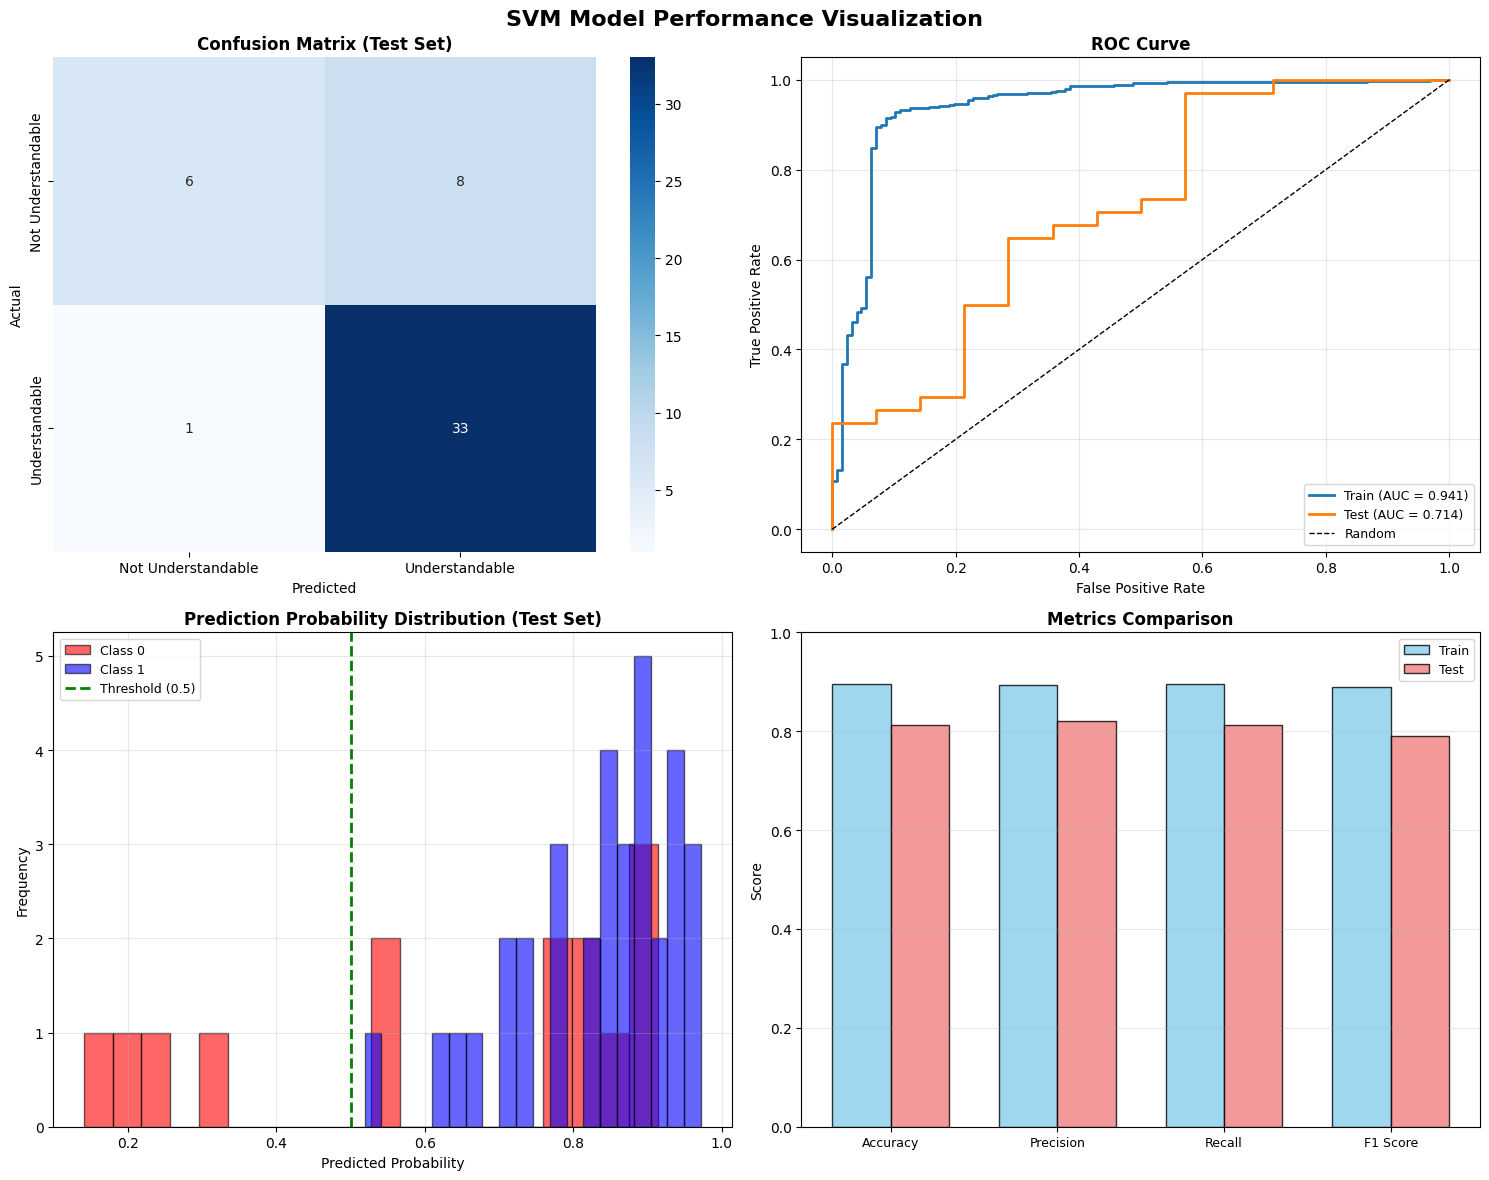

✅ Visualizations created!

FEATURE IMPORTANCE ANALYSIS

📊 Support Vectors Analysis:
   Number of support vectors for Class 0: 107
   Number of support vectors for Class 1: 152
   Total support vectors: 259
   Support vector ratio: 51.29%

💡 For non-linear kernels, feature importance is not directly available.
   Consider using permutation importance or SHAP values for detailed analysis.


In [13]:

# ============================================================================
# STEP 10: Visualization
# ============================================================================
print("\n" + "=" * 80)
print("VISUALIZING RESULTS")
print("=" * 80)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('SVM Model Performance Visualization', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Not Understandable', 'Understandable'],
            yticklabels=['Not Understandable', 'Understandable'])
ax1.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=10)
ax1.set_xlabel('Predicted', fontsize=10)

# 2. ROC Curve
from sklearn.metrics import roc_curve
ax2 = axes[0, 1]
fpr_train, tpr_train, _ = roc_curve(y_train_values, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test_values, y_test_proba)
ax2.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_auc:.3f})', linewidth=2)
ax2.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.3f})', linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(y_test_proba[y_test_values == 0], bins=20, alpha=0.6, label='Class 0', color='red', edgecolor='black')
ax3.hist(y_test_proba[y_test_values == 1], bins=20, alpha=0.6, label='Class 1', color='blue', edgecolor='black')
ax3.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax3.set_xlabel('Predicted Probability', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Prediction Probability Distribution (Test Set)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# 4. Metrics Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, train_scores, width, label='Train', alpha=0.8, color='skyblue', edgecolor='black')
ax4.bar(x + width/2, test_scores, width, label='Test', alpha=0.8, color='lightcoral', edgecolor='black')
ax4.set_ylabel('Score', fontsize=10)
ax4.set_title('Metrics Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, fontsize=9)
ax4.legend(fontsize=9)
ax4.set_ylim([0, 1])
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

# ============================================================================
# STEP 11: Feature Importance Analysis
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# For SVM, we can analyze feature importance using coefficients (for linear kernel)
# or by analyzing support vectors
if grid_search_svm.best_params_['kernel'] == 'linear':
    # Linear SVM: use coefficients as feature importance
    feature_importance = np.abs(best_model_svm.coef_[0])
    feature_names = x_train.columns.tolist() if hasattr(x_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    print(f"\n📊 Top 10 Most Important Features (Linear SVM Coefficients):")
    print(importance_df.head(10).to_string(index=False))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['Feature'].values)
    plt.xlabel('Feature Importance (|Coefficient|)', fontsize=11)
    plt.title('Top 15 Feature Importances (Linear SVM)', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    # For non-linear kernels, we can analyze support vectors
    n_support_vectors = best_model_svm.n_support_
    print(f"\n📊 Support Vectors Analysis:")
    print(f"   Number of support vectors for Class 0: {n_support_vectors[0]}")
    print(f"   Number of support vectors for Class 1: {n_support_vectors[1]}")
    print(f"   Total support vectors: {best_model_svm.n_support_.sum()}")
    print(f"   Support vector ratio: {best_model_svm.n_support_.sum() / len(y_train_values):.2%}")
    print(f"\n💡 For non-linear kernels, feature importance is not directly available.")
    print(f"   Consider using permutation importance or SHAP values for detailed analysis.")


In [14]:
# ============================================================================
# STEP 12: Save Model and Parameters
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODEL AND PARAMETERS")
print("=" * 80)

# Save the trained model
model_filename = 'ai_svm_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model_svm, f)
print(f"✅ Model saved as: {model_filename}")

# Save the scaler (important for preprocessing new data)
scaler_filename = 'ai_svm_scaler.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved as: {scaler_filename}")

# Save the best parameters
params_filename = 'ai_svm_parameters.pkl'
best_params_to_save = {
    'best_params': grid_search_svm.best_params_,
    'best_cv_score': grid_search_svm.best_score_,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'training_time': elapsed_time
}
with open(params_filename, 'wb') as f:
    pickle.dump(best_params_to_save, f)
print(f"✅ Parameters saved as: {params_filename}")

print("\n" + "=" * 80)
print("✅ SVM MODEL TRAINING COMPLETE!")
print("=" * 80)



SAVING MODEL AND PARAMETERS
✅ Model saved as: ai_svm_model.pkl
✅ Scaler saved as: ai_svm_scaler.pkl
✅ Parameters saved as: ai_svm_parameters.pkl

✅ SVM MODEL TRAINING COMPLETE!


## XGBOost

In [25]:
# ============================================================================
# XGBOOST MODEL: COMPLETE TRAINING PIPELINE
# ============================================================================
# This cell implements:
# - Hyperparameter tuning with RandomizedSearchCV (faster than GridSearchCV)
# - 5-fold cross-validation
# - Retraining on full training set
# - Comprehensive evaluation and visualization
# - Feature importance analysis
# - Model and parameter saving
# ============================================================================

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
from tqdm import tqdm
from tqdm.notebook import tqdm as tqdm_notebook
import threading
warnings.filterwarnings('ignore')

print("=" * 80)
print("XGBOOST MODEL TRAINING")
print("=" * 80)

# ============================================================================
# STEP 1: Prepare Data for Training
# ============================================================================
# Extract labels as numpy arrays (assuming y_train and y_test are DataFrames)
# Convert to 1D arrays for sklearn
y_train_values = y_train['is_understandable'].values if hasattr(y_train, 'columns') else y_train.values.flatten()
y_test_values = y_test['is_understandable'].values if hasattr(y_test, 'columns') else y_test.values.flatten()

# Convert features to numpy arrays
X_train = x_train.values
X_test = x_test.values

print(f"\n📊 Data Preparation:")
print(f"   Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"   Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"   Training labels distribution:")
print(f"      - Class 0: {np.sum(y_train_values == 0)} ({np.sum(y_train_values == 0)/len(y_train_values)*100:.1f}%)")
print(f"      - Class 1: {np.sum(y_train_values == 1)} ({np.sum(y_train_values == 1)/len(y_train_values)*100:.1f}%)")

# Note: XGBoost doesn't require feature scaling, but we can still use it if needed
# For this implementation, we'll use raw features (XGBoost handles scaling internally)

# ============================================================================
# STEP 2: Define Hyperparameter Distribution (AGGRESSIVE Anti-Overfitting)
# ============================================================================
# Hyperparameter distribution with AGGRESSIVE regularization to combat severe overfitting
# Key strategies: very shallow trees, very strong regularization, heavy subsampling
# RandomizedSearchCV will randomly sample from these distributions

param_dist_xgb = {
    # Learning rate (eta) - lower values help prevent overfitting
    'learning_rate': [0.01, 0.05, 0.1],  # Further reduced - focus on very low rates
    
    # Maximum depth of trees - CRITICAL: VERY shallow trees to prevent overfitting
    'max_depth': [2, 3, 4],  # Aggressively reduced - no trees deeper than 4
    
    # Minimum child weight - MUCH higher values = very conservative = less overfitting
    'min_child_weight': [5, 7, 10, 15, 20],  # Significantly increased
    
    # Subsample ratio - LOWER values = more randomness = less overfitting
    'subsample': [0.4, 0.5, 0.6, 0.7],  # Further reduced - more aggressive subsampling
    
    # Column subsample - LOWER values = more feature randomness = less overfitting
    'colsample_bytree': [0.4, 0.5, 0.6, 0.7],  # Further reduced
    
    # L2 regularization (alpha) - VERY STRONG regularization
    'reg_alpha': [1.0, 2.0, 5.0, 10.0, 20.0],  # Much stronger regularization
    
    # L1 regularization (lambda) - VERY STRONG regularization
    'reg_lambda': [2.0, 5.0, 10.0, 20.0, 30.0],  # Much stronger regularization
    
    # Number of boosting rounds - fewer trees with stronger regularization
    'n_estimators': [50, 100, 150],  # Further reduced - fewer trees
    
    # Gamma (min_split_loss) - minimum loss reduction required to make a split
    # Higher values = more conservative splitting = less overfitting
    'gamma': [0.5, 1.0, 2.0, 5.0, 10.0],  # Higher values to prevent unnecessary splits
    
    # Scale positive weight for imbalanced classes
    'scale_pos_weight': [1, 2, 3, 4]  # Ratio of negative to positive samples
}

# Number of random parameter combinations to try
# Increased to 400 to better explore the regularization space
n_iter_xgb = 3000  # Test 400 random combinations (focus on finding good regularization)

# Calculate total possible combinations (for reference)
total_possible_combinations = (
    len(param_dist_xgb['learning_rate']) * 
    len(param_dist_xgb['max_depth']) * 
    len(param_dist_xgb['min_child_weight']) * 
    len(param_dist_xgb['subsample']) * 
    len(param_dist_xgb['colsample_bytree']) * 
    len(param_dist_xgb['reg_alpha']) * 
    len(param_dist_xgb['reg_lambda']) * 
    len(param_dist_xgb['n_estimators']) * 
    len(param_dist_xgb['scale_pos_weight'])
)

print(f"\n🔍 Hyperparameter Distribution (AGGRESSIVE Anti-Overfitting):")
print(f"   Learning rate: {len(param_dist_xgb['learning_rate'])} options (very low: 0.01-0.1)")
print(f"   Max depth: {len(param_dist_xgb['max_depth'])} options (VERY shallow: 2-4 only)")
print(f"   Min child weight: {len(param_dist_xgb['min_child_weight'])} options (high: 5-20)")
print(f"   Subsample: {len(param_dist_xgb['subsample'])} options (low: 0.4-0.7)")
print(f"   Colsample bytree: {len(param_dist_xgb['colsample_bytree'])} options (low: 0.4-0.7)")
print(f"   Reg alpha (L2): {len(param_dist_xgb['reg_alpha'])} options (VERY strong: 1.0-20.0)")
print(f"   Reg lambda (L1): {len(param_dist_xgb['reg_lambda'])} options (VERY strong: 2.0-30.0)")
print(f"   N estimators: {len(param_dist_xgb['n_estimators'])} options (fewer: 50-150)")
print(f"   Gamma: {len(param_dist_xgb['gamma'])} options (high: 0.5-10.0)")
print(f"   Scale pos weight: {len(param_dist_xgb['scale_pos_weight'])} options")
print(f"   Total possible combinations: {total_possible_combinations:,}")
print(f"\n🎲 RandomizedSearchCV Configuration:")
print(f"   Number of random combinations to test: {n_iter_xgb}")
print(f"   With 5-fold CV: ~{n_iter_xgb * 5:,} model fits")
print(f"\n💡 AGGRESSIVE Anti-Overfitting Strategy:")
print(f"   ⚠️  Very shallow trees (max_depth: 2-4 only)")
print(f"   ⚠️  Very strong regularization (reg_alpha: 1-20, reg_lambda: 2-30)")
print(f"   ⚠️  Heavy subsampling (subsample/colsample: 0.4-0.7)")
print(f"   ⚠️  High min_child_weight (5-20 for conservative splitting)")
print(f"   ⚠️  High gamma (0.5-10.0 to prevent unnecessary splits)")
print(f"   ⚠️  Fewer trees (50-150 estimators)")
print(f"\n🎯 Goal: Reduce train-test gap from ~0.24 to <0.10")
print(f"\n⏰ Estimated time (based on 0.13s per CV run):")
estimated_time = (n_iter_xgb * 5 * 0.13) / 60  # minutes
print(f"   Single thread: ~{estimated_time:.1f} minutes")
print(f"   Multi-threaded (n_jobs=-1): ~{estimated_time/3.5:.1f} minutes")

# ============================================================================
# STEP 3: Setup Cross-Validation
# ============================================================================
cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================================
# STEP 4: Initialize Base Model
# ============================================================================
base_model_xgb = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # For binary classification
    use_label_encoder=False,  # Avoid deprecation warning
    tree_method='hist'  # Faster training
)

# ============================================================================
# STEP 5: Perform Randomized Search with Cross-Validation (with Progress Bar)
# ============================================================================
print("\n" + "=" * 80)
print("STARTING RANDOMIZED SEARCH WITH 5-FOLD CROSS-VALIDATION")
print("=" * 80)
print(f"\n💡 Strategy: RandomizedSearchCV will randomly sample {n_iter_xgb} parameter")
print("   combinations from the distribution, making it much faster than GridSearchCV.")
print("\n⏳ This may take a while. Please wait...\n")

# Create RandomizedSearchCV with verbose=0 (we'll use tqdm instead)
random_search_xgb = RandomizedSearchCV(
    estimator=base_model_xgb,
    param_distributions=param_dist_xgb,
    n_iter=n_iter_xgb,  # Number of random parameter combinations to try
    cv=cv_xgb,
    scoring='f1_weighted',  # Use F1-weighted for imbalanced datasets (better than accuracy)
    n_jobs=-1,  # Use all available CPUs
    verbose=0,  # Set to 0, we'll use tqdm for progress
    random_state=42,  # For reproducibility
    return_train_score=True  # Return training scores for overfitting check
)

# Calculate total number of fits (n_iter * CV folds)
total_fits = n_iter_xgb * 5  # 5-fold CV

# Create progress bar
print("📊 Starting grid search with progress tracking...")
pbar = tqdm_notebook(total=total_fits, desc='Grid Search Progress', unit='fit', 
                     bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]')

start_time_xgb = time.time()

# Use threading to update progress bar periodically
import threading

def update_progress_bar():
    """Background thread to update progress bar by checking cv_results_"""
    last_count = 0
    check_interval = 0.1  # Check very frequently (every 0.1 seconds)
    estimated_time_per_fit = None
    fits_completed = 0
    fit_start_time = None
    
    while pbar.n < total_fits:
        time.sleep(check_interval)
        try:
            # Check if random_search has cv_results_ attribute
            if hasattr(random_search_xgb, 'cv_results_'):
                if random_search_xgb.cv_results_ is not None:
                    # Try multiple ways to check progress
                    if 'mean_test_score' in random_search_xgb.cv_results_:
                        current_count = len(random_search_xgb.cv_results_['mean_test_score'])
                        if current_count > last_count:
                            # Update progress: each parameter combination = 5 CV folds
                            increment = (current_count - last_count) * 5
                            pbar.update(min(increment, total_fits - pbar.n))
                            last_count = current_count
                            fits_completed += increment
                            
                            # Estimate time per fit for better progress tracking
                            if fit_start_time is None:
                                fit_start_time = time.time()
                            elif fits_completed > 10:  # After some fits, estimate time
                                elapsed = time.time() - fit_start_time
                                estimated_time_per_fit = elapsed / fits_completed
                    # Also check params if available
                    elif 'params' in random_search_xgb.cv_results_:
                        current_count = len(random_search_xgb.cv_results_['params'])
                        if current_count > last_count:
                            increment = (current_count - last_count) * 5
                            pbar.update(min(increment, total_fits - pbar.n))
                            last_count = current_count
                            fits_completed += increment
                            
                            if fit_start_time is None:
                                fit_start_time = time.time()
                            elif fits_completed > 10:
                                elapsed = time.time() - fit_start_time
                                estimated_time_per_fit = elapsed / fits_completed
                    
                    # If we have an estimate and no recent updates, use time-based estimation
                    if estimated_time_per_fit and fits_completed > 0 and pbar.n < total_fits:
                        elapsed_since_start = time.time() - fit_start_time
                        estimated_completed = int(elapsed_since_start / estimated_time_per_fit)
                        if estimated_completed > pbar.n and estimated_completed <= total_fits:
                            # Update based on time estimate (but don't go backwards)
                            pbar.n = min(estimated_completed, total_fits - 1)
                            pbar.refresh()
        except (AttributeError, KeyError, TypeError):
            # RandomizedSearchCV not ready yet, continue waiting
            pass
        except Exception as e:
            # Any other error, just continue
            pass

# Start progress updater thread
progress_thread = threading.Thread(target=update_progress_bar, daemon=True)
progress_thread.start()

# Fit the model with progress tracking
try:
    random_search_xgb.fit(X_train, y_train_values)
    
    # After fitting, ensure we update to the correct final count
    if hasattr(random_search_xgb, 'cv_results_') and random_search_xgb.cv_results_ is not None:
        if 'mean_test_score' in random_search_xgb.cv_results_:
            final_count = len(random_search_xgb.cv_results_['mean_test_score'])
            # Update to reflect actual progress
            final_fits = final_count * 5
            if pbar.n < final_fits:
                pbar.update(final_fits - pbar.n)
finally:
    # Ensure progress bar is complete
    pbar.n = total_fits
    pbar.refresh()
    pbar.close()

elapsed_time_xgb = time.time() - start_time_xgb

print(f"\n✅ Randomized search completed!")
print(f"   Total time: {elapsed_time_xgb/60:.1f} minutes ({elapsed_time_xgb:.1f} seconds)")
print(f"   Tested {n_iter_xgb} random parameter combinations")

# ============================================================================
# STEP 6: Display Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("BEST PARAMETERS FROM RANDOMIZED SEARCH")
print("=" * 80)
print(f"\n🏆 Best Parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n📊 Best Cross-Validation Score (F1-weighted): {random_search_xgb.best_score_:.4f}")

# Check for overfitting
if 'mean_train_score' in random_search_xgb.cv_results_:
    best_idx_xgb = random_search_xgb.best_index_
    train_cv_score_xgb = random_search_xgb.cv_results_['mean_train_score'][best_idx_xgb]
    test_cv_score_xgb = random_search_xgb.cv_results_['mean_test_score'][best_idx_xgb]
    cv_gap_xgb = train_cv_score_xgb - test_cv_score_xgb
    
    print(f"\n📊 Cross-Validation Scores (F1-weighted):")
    print(f"   Train CV Score: {train_cv_score_xgb:.4f}")
    print(f"   Test CV Score: {test_cv_score_xgb:.4f}")
    print(f"   Gap: {cv_gap_xgb:.4f}")
    
    if cv_gap_xgb > 0.15:
        print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
    elif cv_gap_xgb > 0.10:
        print(f"   ⚠️  CAUTION: Moderate gap detected.")
    else:
        print(f"   ✅ Good: Gap is acceptable.")

# ============================================================================
# STEP 7: Retrain on Full Training Set with Best Parameters
# ============================================================================
print("\n" + "=" * 80)
print("RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS")
print("=" * 80)

# Create model with best parameters
best_model_xgb = xgb.XGBClassifier(
    learning_rate=random_search_xgb.best_params_['learning_rate'],
    max_depth=random_search_xgb.best_params_['max_depth'],
    min_child_weight=random_search_xgb.best_params_['min_child_weight'],
    subsample=random_search_xgb.best_params_['subsample'],
    colsample_bytree=random_search_xgb.best_params_['colsample_bytree'],
    reg_alpha=random_search_xgb.best_params_['reg_alpha'],
    reg_lambda=random_search_xgb.best_params_['reg_lambda'],
    n_estimators=random_search_xgb.best_params_['n_estimators'],
    gamma=random_search_xgb.best_params_.get('gamma', 0),  # Use get() in case gamma wasn't in best params
    scale_pos_weight=random_search_xgb.best_params_['scale_pos_weight'],
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist'
)

print("\n🔄 Training on full training set with aggressive regularization...")

# Note: With the aggressive regularization parameters we've set, early stopping may not be necessary
# The shallow trees, strong regularization, and heavy subsampling should prevent overfitting
# However, we can still use a validation set to monitor performance

# Split training data for monitoring (use 20% as validation set)
from sklearn.model_selection import train_test_split
X_train_fit, X_train_val, y_train_fit, y_train_val = train_test_split(
    X_train, y_train_values, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_values
)

print(f"   Training set: {X_train_fit.shape[0]} samples")
print(f"   Validation set (for monitoring): {X_train_val.shape[0]} samples")

# Train with evaluation set for monitoring (but don't use early stopping to avoid API issues)
# The aggressive regularization should be sufficient
best_model_xgb.fit(
    X_train_fit, y_train_fit,
    eval_set=[(X_train_val, y_train_val)],
    verbose=False
)

# Check if we can get best iteration (some XGBoost versions store this)
best_iteration = getattr(best_model_xgb, 'best_iteration', None)
if best_iteration is None:
    # If best_iteration is not available, use the specified n_estimators
    best_iteration = random_search_xgb.best_params_['n_estimators']
    print(f"   Using {best_iteration} trees with aggressive regularization")
else:
    print(f"   Best iteration: {best_iteration} (out of {random_search_xgb.best_params_['n_estimators']})")

# Create final model with optimal parameters and retrain on FULL training set
best_model_xgb_final = xgb.XGBClassifier(
    learning_rate=random_search_xgb.best_params_['learning_rate'],
    max_depth=random_search_xgb.best_params_['max_depth'],
    min_child_weight=random_search_xgb.best_params_['min_child_weight'],
    subsample=random_search_xgb.best_params_['subsample'],
    colsample_bytree=random_search_xgb.best_params_['colsample_bytree'],
    reg_alpha=random_search_xgb.best_params_['reg_alpha'],
    reg_lambda=random_search_xgb.best_params_['reg_lambda'],
    n_estimators=best_iteration,  # Use optimal number if available
    gamma=random_search_xgb.best_params_.get('gamma', 0),
    scale_pos_weight=random_search_xgb.best_params_['scale_pos_weight'],
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method='hist'
)

# Retrain on FULL training set with optimal parameters
print(f"   Retraining on full training set ({X_train.shape[0]} samples)...")
best_model_xgb_final.fit(X_train, y_train_values)
best_model_xgb = best_model_xgb_final  # Replace with final model
print("✅ Model trained on full training set with aggressive regularization!")

# ============================================================================
# STEP 8: Evaluate on Test Set
# ============================================================================
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Make predictions
y_train_pred_xgb = best_model_xgb.predict(X_train)
y_test_pred_xgb = best_model_xgb.predict(X_test)

# Get prediction probabilities (for ROC-AUC)
y_train_proba_xgb = best_model_xgb.predict_proba(X_train)[:, 1]
y_test_proba_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
train_accuracy_xgb = accuracy_score(y_train_values, y_train_pred_xgb)
test_accuracy_xgb = accuracy_score(y_test_values, y_test_pred_xgb)

train_precision_xgb = precision_score(y_train_values, y_train_pred_xgb, average='weighted', zero_division=0)
test_precision_xgb = precision_score(y_test_values, y_test_pred_xgb, average='weighted', zero_division=0)

train_recall_xgb = recall_score(y_train_values, y_train_pred_xgb, average='weighted', zero_division=0)
test_recall_xgb = recall_score(y_test_values, y_test_pred_xgb, average='weighted', zero_division=0)

train_f1_xgb = f1_score(y_train_values, y_train_pred_xgb, average='weighted', zero_division=0)
test_f1_xgb = f1_score(y_test_values, y_test_pred_xgb, average='weighted', zero_division=0)

train_auc_xgb = roc_auc_score(y_train_values, y_train_proba_xgb)
test_auc_xgb = roc_auc_score(y_test_values, y_test_proba_xgb)

# Confusion matrices
train_cm_xgb = confusion_matrix(y_train_values, y_train_pred_xgb)
test_cm_xgb = confusion_matrix(y_test_values, y_test_pred_xgb)

# Display results
print("\n📊 Training Set Performance:")
print(f"   Accuracy:  {train_accuracy_xgb:.4f}")
print(f"   Precision: {train_precision_xgb:.4f}")
print(f"   Recall:    {train_recall_xgb:.4f}")
print(f"   F1 Score:  {train_f1_xgb:.4f}")
print(f"   AUC-ROC:   {train_auc_xgb:.4f}")

print("\n📊 Test Set Performance (FINAL EVALUATION):")
print(f"   ✅ Test Accuracy:  {test_accuracy_xgb:.4f}")
print(f"   ✅ Test Precision: {test_precision_xgb:.4f}")
print(f"   ✅ Test Recall:    {test_recall_xgb:.4f}")
print(f"   ✅ Test F1 Score:  {test_f1_xgb:.4f}")
print(f"   ✅ Test AUC-ROC:   {test_auc_xgb:.4f}")

print("\n📊 Confusion Matrix (Test Set):")
print("   (Rows = Actual, Columns = Predicted)")
print(f"   [[Class 0→0  Class 0→1]")
print(f"    [Class 1→0  Class 1→1]]")
print(test_cm_xgb)

print("\n📊 Classification Report (Test Set):")
print(classification_report(y_test_values, y_test_pred_xgb, target_names=['Not Understandable', 'Understandable']))

# Overfitting check
overfitting_gap_xgb = train_accuracy_xgb - test_accuracy_xgb
print(f"\n⚠️  Overfitting Check:")
print(f"   Train-Test Accuracy Gap: {overfitting_gap_xgb:.4f}")
if overfitting_gap_xgb > 0.15:
    print(f"   ⚠️  WARNING: Large gap detected! Model may be overfitting.")
elif overfitting_gap_xgb > 0.10:
    print(f"   ⚠️  CAUTION: Moderate gap detected.")
else:
    print(f"   ✅ Good: Gap is acceptable.")



XGBOOST MODEL TRAINING

📊 Data Preparation:
   Training set: 505 samples, 31 features
   Test set: 48 samples, 31 features
   Training labels distribution:
      - Class 0: 127 (25.1%)
      - Class 1: 378 (74.9%)

🔍 Hyperparameter Distribution (AGGRESSIVE Anti-Overfitting):
   Learning rate: 3 options (very low: 0.01-0.1)
   Max depth: 3 options (VERY shallow: 2-4 only)
   Min child weight: 5 options (high: 5-20)
   Subsample: 4 options (low: 0.4-0.7)
   Colsample bytree: 4 options (low: 0.4-0.7)
   Reg alpha (L2): 5 options (VERY strong: 1.0-20.0)
   Reg lambda (L1): 5 options (VERY strong: 2.0-30.0)
   N estimators: 3 options (fewer: 50-150)
   Gamma: 5 options (high: 0.5-10.0)
   Scale pos weight: 4 options
   Total possible combinations: 216,000

🎲 RandomizedSearchCV Configuration:
   Number of random combinations to test: 3000
   With 5-fold CV: ~15,000 model fits

💡 AGGRESSIVE Anti-Overfitting Strategy:
   ⚠️  Very shallow trees (max_depth: 2-4 only)
   ⚠️  Very strong regulariz

Grid Search Progress:   0%|          | 0/15000 [00:00<?, ?fit/s]


✅ Randomized search completed!
   Total time: 0.2 minutes (13.9 seconds)
   Tested 3000 random parameter combinations

BEST PARAMETERS FROM RANDOMIZED SEARCH

🏆 Best Parameters:
   subsample: 0.4
   scale_pos_weight: 1
   reg_lambda: 2.0
   reg_alpha: 2.0
   n_estimators: 100
   min_child_weight: 5
   max_depth: 2
   learning_rate: 0.1
   gamma: 2.0
   colsample_bytree: 0.7

📊 Best Cross-Validation Score (F1-weighted): 0.7900

📊 Cross-Validation Scores (F1-weighted):
   Train CV Score: 0.8192
   Test CV Score: 0.7900
   Gap: 0.0292
   ✅ Good: Gap is acceptable.

RETRAINING ON FULL TRAINING SET WITH BEST PARAMETERS

🔄 Training on full training set with aggressive regularization...
   Training set: 404 samples
   Validation set (for monitoring): 101 samples
   Using 100 trees with aggressive regularization
   Retraining on full training set (505 samples)...
✅ Model trained on full training set with aggressive regularization!

EVALUATING ON TEST SET

📊 Training Set Performance:
   Accura


VISUALIZING RESULTS


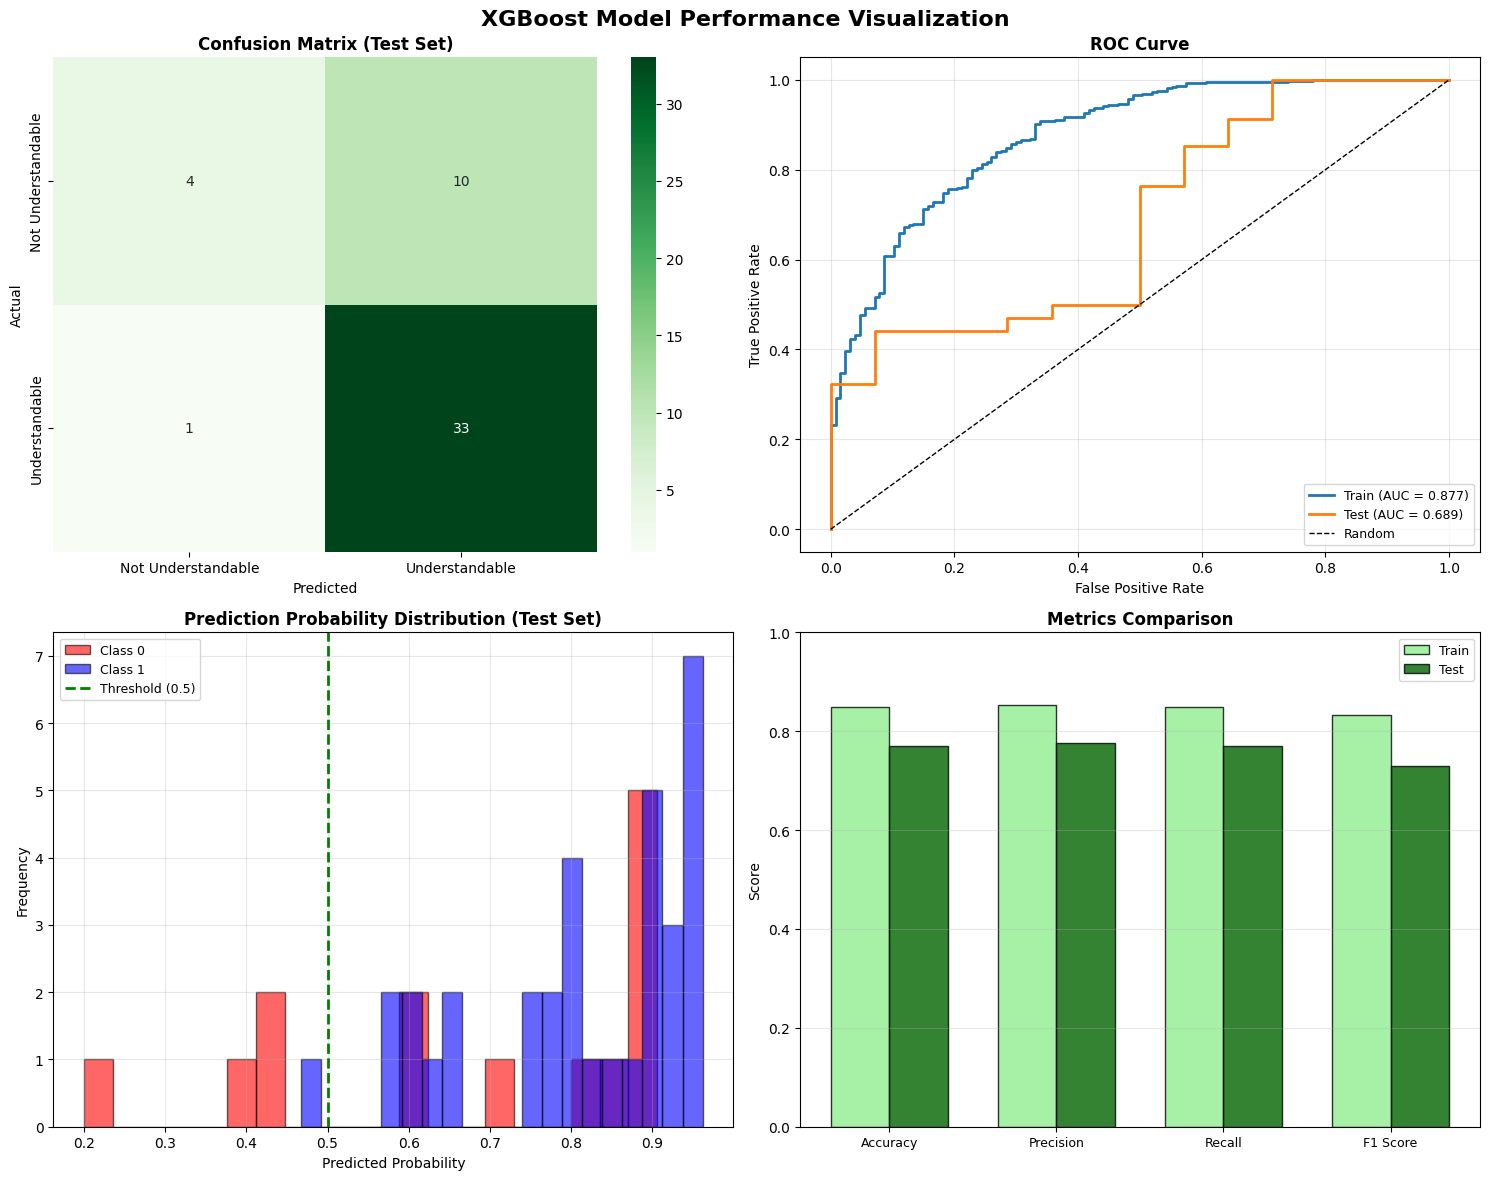

✅ Visualizations created!

FEATURE IMPORTANCE ANALYSIS

📊 Top 15 Most Important Features:
                      Feature  Importance
  average_dependency_distance    0.092945
          meta_video_duration    0.090508
            pronoun_frequency    0.070415
   subordinate_clause_density    0.064100
            lexical_diversity    0.046449
              condition_ratio    0.044844
meta_description_unique_words    0.038804
                   word_count    0.037705
          average_word_length    0.037520
       rare_term_ratio_unique    0.036838
         term_clustering_gini    0.035729
                symptom_ratio    0.035268
        meta_subscriber_count    0.034685
            syntax_tree_depth    0.032518
               location_ratio    0.032256


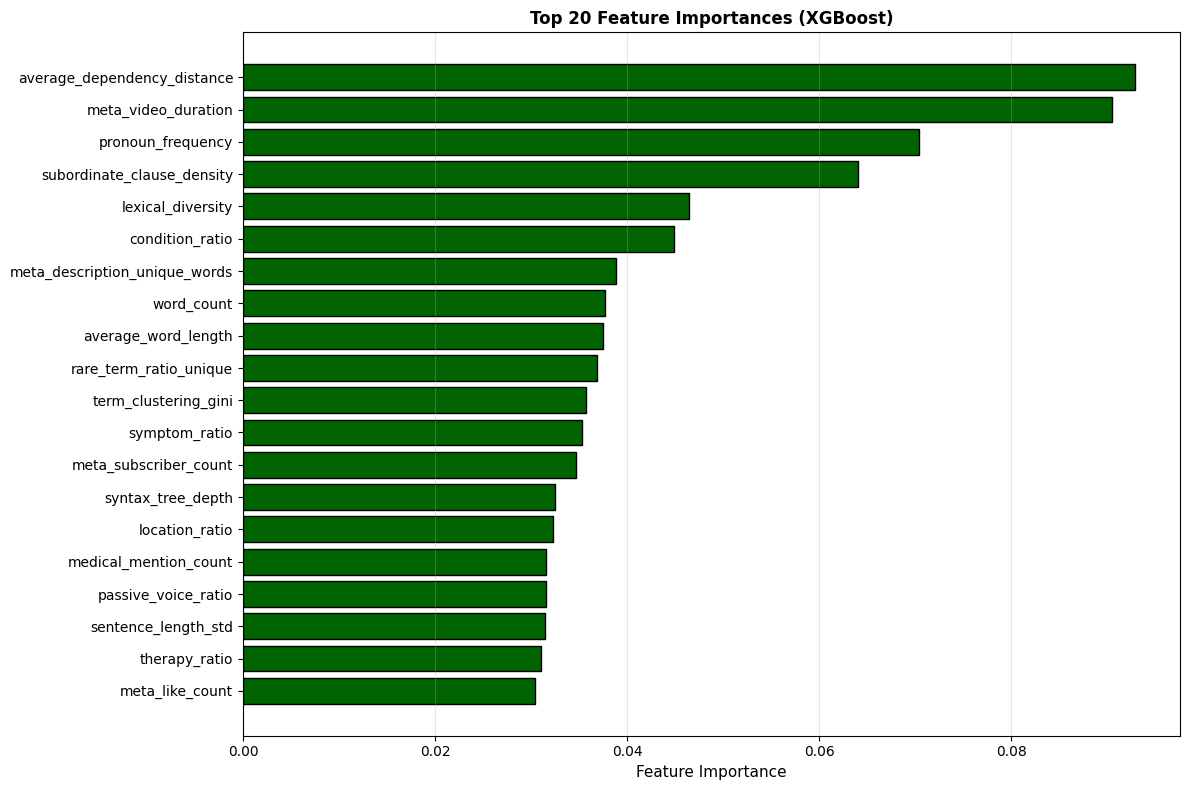

In [26]:

# ============================================================================
# STEP 9: Visualization
# ============================================================================
print("\n" + "=" * 80)
print("VISUALIZING RESULTS")
print("=" * 80)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('XGBoost Model Performance Visualization', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(test_cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax1, 
            xticklabels=['Not Understandable', 'Understandable'],
            yticklabels=['Not Understandable', 'Understandable'])
ax1.set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual', fontsize=10)
ax1.set_xlabel('Predicted', fontsize=10)

# 2. ROC Curve
from sklearn.metrics import roc_curve
ax2 = axes[0, 1]
fpr_train_xgb, tpr_train_xgb, _ = roc_curve(y_train_values, y_train_proba_xgb)
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test_values, y_test_proba_xgb)
ax2.plot(fpr_train_xgb, tpr_train_xgb, label=f'Train (AUC = {train_auc_xgb:.3f})', linewidth=2)
ax2.plot(fpr_test_xgb, tpr_test_xgb, label=f'Test (AUC = {test_auc_xgb:.3f})', linewidth=2)
ax2.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)

# 3. Prediction Distribution
ax3 = axes[1, 0]
ax3.hist(y_test_proba_xgb[y_test_values == 0], bins=20, alpha=0.6, label='Class 0', color='red', edgecolor='black')
ax3.hist(y_test_proba_xgb[y_test_values == 1], bins=20, alpha=0.6, label='Class 1', color='blue', edgecolor='black')
ax3.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Threshold (0.5)')
ax3.set_xlabel('Predicted Probability', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.set_title('Prediction Probability Distribution (Test Set)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# 4. Metrics Comparison
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_scores_xgb = [train_accuracy_xgb, train_precision_xgb, train_recall_xgb, train_f1_xgb]
test_scores_xgb = [test_accuracy_xgb, test_precision_xgb, test_recall_xgb, test_f1_xgb]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, train_scores_xgb, width, label='Train', alpha=0.8, color='lightgreen', edgecolor='black')
ax4.bar(x + width/2, test_scores_xgb, width, label='Test', alpha=0.8, color='darkgreen', edgecolor='black')
ax4.set_ylabel('Score', fontsize=10)
ax4.set_title('Metrics Comparison', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics, fontsize=9)
ax4.legend(fontsize=9)
ax4.set_ylim([0, 1])
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

# ============================================================================
# STEP 10: Feature Importance Analysis
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# XGBoost provides feature importance
feature_importance_xgb = best_model_xgb.feature_importances_
feature_names_xgb = x_train.columns.tolist() if hasattr(x_train, 'columns') else [f'Feature_{i}' for i in range(X_train.shape[1])]

importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': feature_importance_xgb
}).sort_values('Importance', ascending=False)

print(f"\n📊 Top 15 Most Important Features:")
print(importance_df_xgb.head(15).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features_xgb = importance_df_xgb.head(20)
plt.barh(range(len(top_features_xgb)), top_features_xgb['Importance'].values, color='darkgreen', edgecolor='black')
plt.yticks(range(len(top_features_xgb)), top_features_xgb['Feature'].values)
plt.xlabel('Feature Importance', fontsize=11)
plt.title('Top 20 Feature Importances (XGBoost)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


In [27]:

# ============================================================================
# STEP 11: Save Model and Parameters
# ============================================================================
print("\n" + "=" * 80)
print("SAVING MODEL AND PARAMETERS")
print("=" * 80)

# Save the trained model
model_filename_xgb = 'ai_xgboost_model.pkl'
with open(model_filename_xgb, 'wb') as f:
    pickle.dump(best_model_xgb, f)
print(f"✅ Model saved as: {model_filename_xgb}")

# Save the best parameters
params_filename_xgb = 'ai_xgboost_parameters.pkl'
best_params_to_save_xgb = {
    'best_params': random_search_xgb.best_params_,
    'n_iter_tested': n_iter_xgb,
    'best_cv_score': random_search_xgb.best_score_,
    'test_accuracy': test_accuracy_xgb,
    'test_precision': test_precision_xgb,
    'test_recall': test_recall_xgb,
    'test_f1': test_f1_xgb,
    'test_auc': test_auc_xgb,
    'training_time': elapsed_time_xgb
}
with open(params_filename_xgb, 'wb') as f:
    pickle.dump(best_params_to_save_xgb, f)
print(f"✅ Parameters saved as: {params_filename_xgb}")

print("\n" + "=" * 80)
print("✅ XGBOOST MODEL TRAINING COMPLETE!")
print("=" * 80)


SAVING MODEL AND PARAMETERS
✅ Model saved as: ai_xgboost_model.pkl
✅ Parameters saved as: ai_xgboost_parameters.pkl

✅ XGBOOST MODEL TRAINING COMPLETE!


# Predict 